In [1]:
# Project-root setup (auto-injected during notebook reorg 2026-05-06).
import sys as _sys
from pathlib import Path as _Path
_p = _Path.cwd().resolve()
while _p != _p.parent and not (_p / "pyproject.toml").exists():
    _p = _p.parent
PROJECT_ROOT = _p if (_p / "pyproject.toml").exists() else _Path.cwd()
if str(PROJECT_ROOT) not in _sys.path:
    _sys.path.insert(0, str(PROJECT_ROOT))
# Also add notebook_modules/ so `from twopoint_lockin import ...` etc. work
# without per-notebook sys.path tweaks. The five .py modules used by these
# notebooks live there now (lockin_extensions, multipoint_lockin_program,
# nv_magnetometry_analysis, odmr_sensitivity, twopoint_lockin).
_nb_modules_dir = PROJECT_ROOT / "notebook_modules"
if _nb_modules_dir.exists() and str(_nb_modules_dir) not in _sys.path:
    _sys.path.insert(0, str(_nb_modules_dir))
print(f"PROJECT_ROOT: {PROJECT_ROOT}")

PROJECT_ROOT: C:\Users\Thoma\Downloads\nv-compact-magnetometer


# Two-point parked lock-in module

Same hardware path as `Lockin_module.ipynb`, but tracking **two** parked frequencies on
**one** ODMR transition instead of 16 parked frequencies across 8 transitions.

| | `Lockin_module.ipynb` | this notebook |
|---|---|---|
| parked frequencies | 16 (8 transitions x 2 flanks) | 2 (1 transition x 2 flanks) |
| peak choice | all transitions that survive pair rejection | the single most pronounced + most symmetric peak |
| output | vector `dBx, dBy, dBz` reconstruction | shift of that one resonance, `df(t)` |
| dwell per batch | 16 x (sig + ref) | 2 x (sig + ref) -> ~8x faster batches |

**No magnetic-field reconstruction here.** Two points constrain one resonance frequency,
which is the field projection along that one NV axis (up to the transition's `df/dB`), not
a vector. What you get is the peak-shift time series, the same quantity produced by
`QDM Heart on Diamond/notebook/full_odmr_calibrated_peak_shift.ipynb`, but sampled at the
FPGA batch rate instead of one point per camera sweep.

Both conversion methods from the QDM-heart notebook are carried over:

* **Method A - exact Lorentzian ratio inversion.** Dip depths `d_i = B - z_i` obey
  `d_i = C g^2 / ((f_i - f0)^2 + g^2)`. The ratio `r = d_minus / d_plus` cancels the
  contrast `C` (and any common laser-power drift), leaving a quadratic in `f0` whose only
  extra input is the linewidth `g = FWHM/2`. Exact for arbitrary shifts and asymmetric
  parking.
* **Method B - linear slope estimate.** `df = [(z_plus - z_minus) - (b_plus - b_minus)] / (m_minus - m_plus)`,
  identical to `nv_toolkit.two_point.estimate_delta_f_mhz`. Valid for shifts small compared
  to the linewidth; used as a cross-check. Divergence between A and B flags that the peak
  moved a significant fraction of its linewidth.

Run order: setup -> ODMR sweep -> Step 1 (pick peak) -> Step 2 (one batch) ->
Step 3 (calibrate) -> Step 4 (live) -> Step 5 (post-process).

# Import and setup

In [2]:
%load_ext autoreload
%matplotlib inline
%autoreload 2

import numpy as np
import matplotlib.pyplot as plt
from copy import copy
import qickdawg as qd
from scipy.optimize import curve_fit

# ===== EDIT THIS: Set your RFSoC IP address =====
RFSOC_IP = '192.168.0.103'

qd.start_client(RFSOC_IP)
print(f"Connected to RFSoC at {RFSOC_IP}")

c:\Users\Thoma\AppData\Local\Programs\Python\Python310\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
QICK library version mismatch: 0.2.386 remote (the board), 0.2.388 local (the PC)
                        This may cause errors, usually KeyError in QickConfig initialization.
                        If this happens, you must bring your versions in sync.


Connected to RFSoC at 192.168.0.103


In [3]:
default_config = qd.NVConfiguration()

# ADC channel: 0 or 1 (run diagnostic above if unsure which has your photodiode)
# 0 for ADC_D and 1 for ADC_C
default_config.adc_channel = 0
default_config.mw_channel = 1
default_config.mw_nqz = 1
default_config.mw_gain = 10500
default_config.laser_gate_pmod = 0
default_config.relax_delay_tns = 500000
# Readout window. This is THE rate knob: the rep is the ADC integration windows and
# essentially nothing else (2 freqs x tau), so the acquisition rate scales as 1/tau.
#
# 213 us was past the sensitivity optimum. Across a 17-point sweep (50-213 us) the dip
# contrast is flat, and sigma_z * sqrt(tau) is constant below ~140 us but rises above it
# -- past ~140 us the readout stops averaging down and starts collecting drift. Measured
# sensitivity is 19.0 +/- 0.8 nT/rtHz for tau <= 140 us against 23.8 +/- 2.0 for
# 150-200 us, so 120 us is 1.75x faster than 213 us at no cost in sensitivity.
# Full analysis: docs/2026-08-06_twopoint_timing/TIMING_AND_NOISE_ANALYSIS.md section 3.
default_config.readout_integration_tus = 120  # auto-sets _treg and _tns

print("Default configuration:")
print(f"  ADC channel:     {default_config.adc_channel}")
print(f"  MW channel:      {default_config.mw_channel}")
print(f"  MW gain:         {default_config.mw_gain}")
print(f"  Relax delay:     {default_config.relax_delay_tns:.0f} ns")
print(f"  Readout window:  {default_config.readout_integration_tus:.1f} us")

Default configuration:
  ADC channel:     0
  MW channel:      1
  MW gain:         10500
  Relax delay:     500000 ns
  Readout window:  120.0 us


In [4]:
# ===== DSA ATTENUATION SETUP (fix 8100-count railing) =====
# Retrieve the soc proxy from qickdawg
import qickdawg as qd
soc = qd.soc  # Access the global soc proxy from start_client()

# Apply DSA to ADC_D (NV PL channel, block "00")
dsa_db = 0  # Start with 6 dB; tune as needed (0-27 dB)
soc.set_adc_attenuator("00", dsa_db)
confirmed_db = soc.get_adc_attenuator("00")
print(f"OK ADC_D DSA set to {confirmed_db} dB")
print(f"  Expected peak PL: ~{int(8100 * 10**(-confirmed_db/20))} counts (was ~8100)")

OK ADC_D DSA set to 0.0 dB
  Expected peak PL: ~8100 counts (was ~8100)


# ODMR reference sweep

The two-point tracker is only as good as the reference sweep it is calibrated against:
the linewidth, baseline and flank slopes all come from this one spectrum. Take it at the
**same bias field, MW power and laser power** you intend to run the live tracker at.

Use a fine `MW_FREQ_STEP_MHZ` (0.25-0.5 MHz) around the peak you plan to track - the
Lorentzian fit and the empirical max-slope placement in Step 1 both improve with it.

In [5]:
# =============================================================================
# ODMR sweep - edit ALL parameters below, then run this cell once.
# Builds config, runs LockinODMR, saves full sweep to CSV (MW on / MW off / contrast).
# =============================================================================
import pandas as pd
from pathlib import Path
from datetime import datetime
import importlib

from IPython.display import FileLink, display

# --- Microwave & timing ---
ODMR_MW_GAIN = 15000              # 0-32767; up if contrast weak, down if saturated
ODMR_PRE_INIT = True             # MW+laser prepulse before sweep
ODMR_REPS = 20                   # averages per frequency point
ODMR_RELAX_DELAY_TREG = 1000    # delay register units between MW on/off segments. Normal = 500, Completely MW Off = 500000. OG = 1000

# --- ADC readout integration (photodiode PL averaging time) ---
ODMR_READOUT_INTEGRATION_TUS = 213   # or set e.g. 50.0 (microseconds). OG = 213

# --- Frequency sweep (MHz) ---
MW_FREQ_START_MHZ = 2680
MW_FREQ_STOP_MHZ = 3070
MW_FREQ_STEP_MHZ = 1             # step size (MHz); 0.5 or 0.25 gives a much better
                                 # Lorentzian fit + max-slope placement in Step 1

# --- CSV export ---
SAVE_ODMR_CSV = True             # set False to only acquire (still defines d, prog_odmr for plots)

# --- If reference should be flat but shows dips: try True (explicit low-gain pulse in ref. window) ---
ODMR_REFERENCE_ZERO_GAIN_PULSE = False
ODMR_REFERENCE_PULSE_GAIN = 1       # use 1 if gain 0 faults; increase only if needed
# --- Only if reference is flat and signal is not (mis-labeled shots), try True ---
ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE = False

# --- Build configuration (inherits adc_channel, mw_channel, laser from default_config) ---
config_odmr = copy(default_config)
config_odmr.odmr_reference_zero_gain_pulse = ODMR_REFERENCE_ZERO_GAIN_PULSE
config_odmr.odmr_reference_pulse_gain = ODMR_REFERENCE_PULSE_GAIN
config_odmr.odmr_lockin_swap_signal_reference = ODMR_LOCKIN_SWAP_SIGNAL_REFERENCE
config_odmr.readout_integration_tus = ODMR_READOUT_INTEGRATION_TUS
config_odmr.mw_gain = ODMR_MW_GAIN
config_odmr.pre_init = ODMR_PRE_INIT
config_odmr.reps = ODMR_REPS
config_odmr.relax_delay_treg = ODMR_RELAX_DELAY_TREG
config_odmr.add_linear_sweep(
    "mw", "fMHz",
    start=MW_FREQ_START_MHZ,
    stop=MW_FREQ_STOP_MHZ,
    delta=MW_FREQ_STEP_MHZ,
)

print("ODMR configuration:")
print(f"  ADC channel: {config_odmr.adc_channel}  MW channel: {config_odmr.mw_channel}  gain: {config_odmr.mw_gain}")
print(f"  Sweep: {config_odmr.mw_start_fMHz:.3f} -> {config_odmr.mw_end_fMHz:.3f} MHz  ({config_odmr.nsweep_points} pts)")
print(f"  reps: {config_odmr.reps}  est. time: {qd.LockinODMR(config_odmr).total_time():.1f} s")

prog_odmr = qd.LockinODMR(config_odmr)
d = prog_odmr.acquire(progress=True)
print("Acquisition done.")

if SAVE_ODMR_CSV:
    odmr_df = pd.DataFrame(
        {
            "frequency_MHz": np.asarray(d.frequencies, dtype=float),
            "photoluminescence_mw_on_ADC": np.asarray(d.signal, dtype=float),
            "photoluminescence_mw_off_ADC": np.asarray(d.reference, dtype=float),
            "contrast_ADC": np.asarray(d.contrast, dtype=float),
            "contrast_percent": np.asarray(d.contrast_percent, dtype=float),
        }
    )
    ts = datetime.now().strftime("%Y%m%d_%H%M%S")
    # Save ODMR sweep CSV to the categorized data store under PROJECT_ROOT/data/odmr_sweeps/
    # so all ODMR runs land in one place regardless of which subfolder the
    # notebook is launched from. PROJECT_ROOT is set by the project_root_setup cell.
    odmr_csv_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    odmr_csv_dir.mkdir(parents=True, exist_ok=True)
    csv_path = odmr_csv_dir / f"odmr_sweep_{ts}.csv"
    odmr_df.to_csv(csv_path, index=False)
    LAST_ODMR_CSV = csv_path
    LAST_ODMR_DF = odmr_df.copy()
    print(f"CSV: {len(odmr_df)} rows -> {csv_path.resolve()}")
    display(FileLink(csv_path.name))


Requested 2680 to 3070 by 1
Instead using 2679.9999996185306 to 3069.9998508453373 by 0.9999996185302735 in 391 steps
ODMR configuration:
  ADC channel: 0  MW channel: 1  gain: 15000
  Sweep: 2680.000 -> 3070.000 MHz  (391 pts)
  reps: 20  est. time: 3.4 s


100%|██████████| 7820/7820 [00:03<00:00, 2226.71it/s]

Acquisition done.
CSV: 391 rows -> C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\odmr_sweeps\odmr_sweep_20260817_142920.csv


c:\Users\Thoma\Downloads\nv-compact-magnetometer\Modules\odmr_sweep_20260817_142920.csv

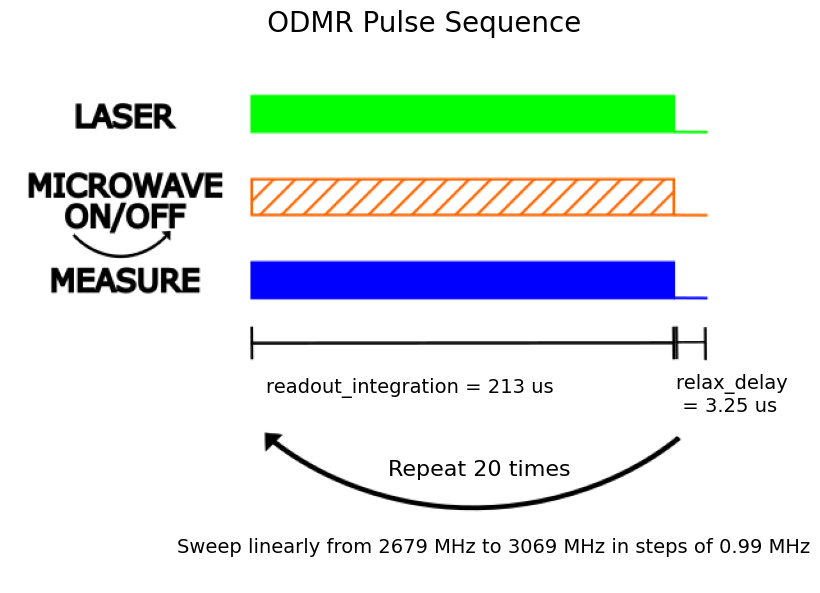

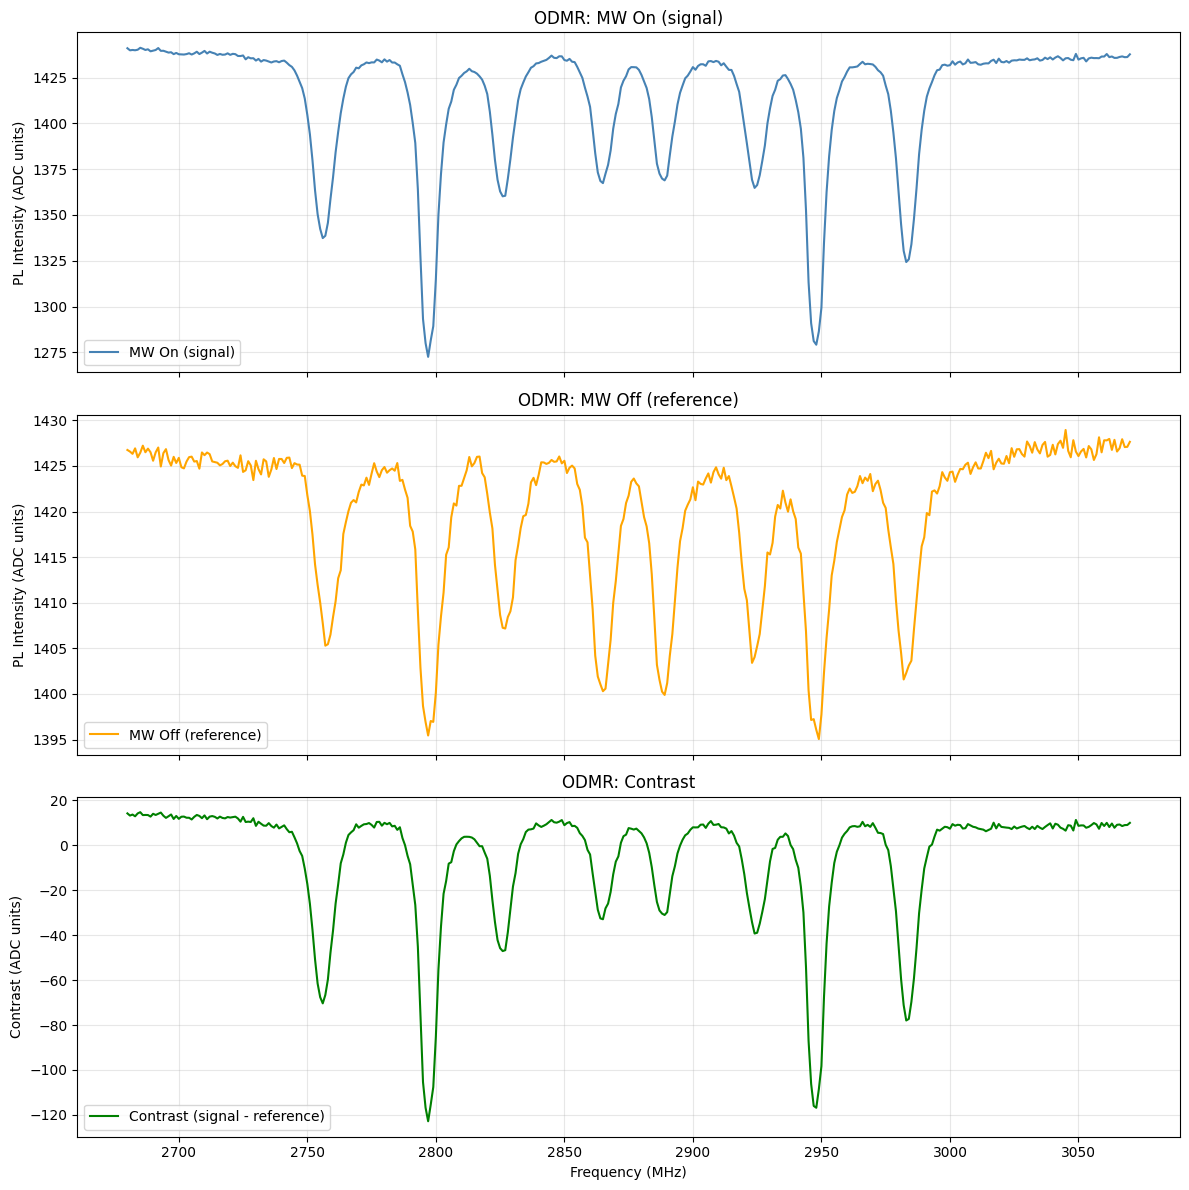

In [6]:
qd.LockinODMR.plot_sequence(config_odmr)

# Plot ODMR spectrum with subplots for MW On, MW Off, and Contrast
fig, axes = plt.subplots(3, 1, figsize=(12, 12), sharex=True)

axes[0].plot(d.frequencies, d.signal, label='MW On (signal)', color='steelblue')
axes[0].set_ylabel('PL Intensity (ADC units)')
axes[0].set_title('ODMR: MW On (signal)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(d.frequencies, d.reference, label='MW Off (reference)', color='orange')
axes[1].set_ylabel('PL Intensity (ADC units)')
axes[1].set_title('ODMR: MW Off (reference)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

axes[2].plot(d.frequencies, d.contrast, label='Contrast (signal - reference)', color='green')
axes[2].set_xlabel('Frequency (MHz)')
axes[2].set_ylabel('Contrast (ADC units)')
axes[2].set_title('ODMR: Contrast')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Two-point lock-in

## Step 1a - Pick the single best peak to track

Every transition in the sweep is fitted, then scored on three things:

* **Pronounced** - dip depth divided by the local high-frequency noise sigma (SNR).
  Deeper dip -> steeper flanks -> more Hz of peak shift per ADC count.
* **Symmetric** - the left and right half-depth half-widths must match, and the two flank
  slopes must match in magnitude. Asymmetry (unresolved hyperfine, an overlapping
  neighbour, a sloping baseline) biases the two-point inversion, because both methods
  assume the same lineshape on either side of `f0`.
* **Well fitted** - RMS residual of a single-Lorentzian fit, relative to the dip depth. A
  poor fit means the single-Lorentzian model the inversion relies on is wrong here.

Four conditions are hard filters rather than scores, and a candidate failing any of them
is listed with its `reject_reason`:

* **Isolation** from the nearest other transition, in units of the peak's own linewidth
  (`MIN_ISOLATION_FWHM`) - a 14 MHz-wide line needs far more room than a 2 MHz one. If a
  neighbour sits inside the fit window, the flank the tracker parks on is not the flank
  the calibration measured.
* **Resolution** - at least `MIN_POINTS_PER_FWHM` sweep points across the linewidth. Every
  kHz this notebook reports is scaled by that linewidth, and a linewidth cannot be measured
  from a sweep that barely samples it.
* **The fit converged** - `gamma` must not sit on either bound.
* **`f0` is actually inside a dip** - if the half-depth crossings are undefined, the
  detector collapsed a hyperfine pair and fitted the bump between its components.

If nothing survives, the cell **raises** with the per-candidate reasons and the sweep step
you would need instead, rather than quietly calibrating on a bad peak. Setting
`FORCE_PEAK_CENTER_MHZ` overrides that and proceeds anyway.

The Lorentzian fit runs **twice**: once in the detection window `FIT_WINDOW_MHZ`, then
again in a window scaled to the linewidth that first pass measured
(`PEAK_FIT_WINDOW_FACTOR x FWHM`, clipped so it cannot swallow a neighbour). Without the
second pass a line much broader than `FIT_WINDOW_MHZ` is fitted over a nearly straight
slice of its own flank, and both the FWHM and the parked placement come out wrong.

Set `FORCE_PEAK_CENTER_MHZ` to override the automatic choice. Step 1b then places the
parked pair on whichever peak this cell selected.

In [7]:
# Step 1a - Choose ONE peak to track.
#
# Difference from Lockin_module: that notebook parks 16 frequencies (8 transitions x 2
# flanks) so nv_toolkit can reconstruct a full B vector. Here we park TWO frequencies on
# ONE transition. That tracks the shift of that resonance -- the field projection along
# that NV axis -- but is NOT enough for a vector reconstruction, so no reconstruction
# cell exists in this notebook.
#
# Candidate detection reuses the same nv_toolkit pipeline as Lockin_module
# (detect -> cluster -> collapse -> local fit -> pair rejection); only the selection,
# the linewidth-scaled refit and the placement that follow are new.
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit
from IPython.display import FileLink, display

# ------------------------------------------------------------------ knobs ---
ODMR_CSV_OVERRIDE = None        # Path("...odmr_sweep_....csv") to analyse a saved sweep

# Candidate detection (same values as Lockin_module).
SNR_THRESHOLD         = 0.8
CLUSTER_MERGE_MHZ     = 3.0
FIT_WINDOW_MHZ        = 8.0     # detection-stage window; the refit below rescales it
MAX_CENTERS           = 8
REQUIRE_PAIRED_PEAKS  = True    # drop fitted dips with no 2870-mirrored partner
PEAK_SEARCH_RANGE_MHZ = None    # e.g. (2820, 2920) to restrict where we look

# Second-pass fit and analysis windows, in units of the measured FWHM.
PEAK_FIT_WINDOW_FACTOR = 3.0    # full refit window = factor x FWHM
SLOPE_SEARCH_FWHM      = 1.5    # flank max-slope search half-width = this x FWHM

# Peak scoring (weights need not sum to 1; they are renormalised).
W_PROMINENCE       = 0.45
W_SYMMETRY         = 0.40
W_FIT              = 0.15
MIN_SNR            = 3.0        # reject candidates shallower than this
MIN_ISOLATION_MHZ  = 5.0        # absolute floor on the distance to the nearest neighbour
MIN_ISOLATION_FWHM = 1.5        # ... and at least this many of the peak's own linewidths
MIN_POINTS_PER_FWHM = 4.0       # the sweep must resolve the line this well to calibrate it
FIT_RESID_SCALE    = 0.10       # residual/depth that halves the fit sub-score

# Manual override: a frequency in MHz forces which peak is tracked (nearest candidate).
FORCE_PEAK_CENTER_MHZ = None

# ------------------------------------------------------- nv_toolkit import ---
_search_roots = [PROJECT_ROOT, Path.cwd(), *Path.cwd().parents]
_nv_repo_names = (".", "NV_Magnetometry_Software", "NV_Magnetometry_Software-main")
NV_REPO_DIR = None
for _root in _search_roots:
    for _repo_name in _nv_repo_names:
        candidate = (_root / _repo_name).resolve()
        if (candidate / "nv_toolkit" / "operator_cli.py").exists():
            NV_REPO_DIR = candidate
            break
    if NV_REPO_DIR is not None:
        break
if NV_REPO_DIR is None:
    raise FileNotFoundError("Could not find an nv_toolkit checkout from the notebook directory")
if str(NV_REPO_DIR) not in sys.path:
    sys.path.insert(0, str(NV_REPO_DIR))

from nv_toolkit.peaks import (
    detect_baseline_corrected_dip_candidates,
    cluster_dip_candidates,
    collapse_candidate_clusters,
    fit_local_dips,
    reject_unpaired_peaks,
)
from nv_toolkit.tui import _suggest_parked_frequencies

# ----------------------------------------------------------- load the sweep ---
if ODMR_CSV_OVERRIDE is not None:
    ODMR_CSV_FOR_PLAN = Path(ODMR_CSV_OVERRIDE)
elif "LAST_ODMR_CSV" in globals() and Path(LAST_ODMR_CSV).exists():
    ODMR_CSV_FOR_PLAN = Path(LAST_ODMR_CSV)
else:
    _odmr_dir = PROJECT_ROOT / "data" / "odmr_sweeps"
    _odmr_files = sorted(_odmr_dir.glob("odmr_sweep_*.csv"))
    if not _odmr_files:
        raise FileNotFoundError(f"No odmr_sweep_*.csv found in {_odmr_dir}")
    ODMR_CSV_FOR_PLAN = _odmr_files[-1]
print(f"Reference ODMR: {ODMR_CSV_FOR_PLAN}")

_odmr_df = pd.read_csv(ODMR_CSV_FOR_PLAN)
freqs_mhz = _odmr_df["frequency_MHz"].to_numpy(dtype=float)
_mw_on  = _odmr_df["photoluminescence_mw_on_ADC"].to_numpy(dtype=float)
_mw_off = _odmr_df["photoluminescence_mw_off_ADC"].to_numpy(dtype=float)
_df_step_mhz = float(np.median(np.diff(freqs_mhz)))

# TWO normalisations, deliberately kept apart (same split as Lockin_module):
#   `measured`      = mw_on / |median(mw_on)|  -> dip DETECTION and fitting only.
#   `spectrum_norm` = mw_on / |median(mw_off)| -> CALIBRATION scale. It matches the live
#     per-point mw_on/|mw_off| ratio, so baselines and slopes live on the same scale as
#     the parked measurements. MW-off has no dips, so its MEDIAN is used rather than the
#     per-bin value, which would inject reference noise into the calibration slopes.
measured      = _mw_on / abs(float(np.nanmedian(_mw_on)))
spectrum_norm = _mw_on / abs(float(np.median(_mw_off)))

# ------------------------------------------------- candidate detection chain ---
candidates = detect_baseline_corrected_dip_candidates(
    freqs_mhz, measured, min_prominence_sigma=SNR_THRESHOLD,
)
clusters = cluster_dip_candidates(candidates, merge_distance_mhz=CLUSTER_MERGE_MHZ)
candidate_centers, _cluster_rows = collapse_candidate_clusters(clusters, max_centers=MAX_CENTERS)

if PEAK_SEARCH_RANGE_MHZ is not None:
    _lo, _hi = float(PEAK_SEARCH_RANGE_MHZ[0]), float(PEAK_SEARCH_RANGE_MHZ[1])
    _n_before = len(candidate_centers)
    candidate_centers = candidate_centers[(candidate_centers >= _lo) & (candidate_centers <= _hi)]
    print(f"Search restricted to {_lo:.0f}-{_hi:.0f} MHz: kept {len(candidate_centers)} of {_n_before} centers.")
    if len(candidate_centers) == 0:
        raise RuntimeError("No candidate centers remain after PEAK_SEARCH_RANGE_MHZ filtering.")

local_fits = fit_local_dips(
    freqs_mhz, measured, candidate_centers,
    window_mhz=FIT_WINDOW_MHZ, hyperfine_merge_mhz=0.0,
)
if REQUIRE_PAIRED_PEAKS:
    kept_fits, rejected_fits = reject_unpaired_peaks(
        local_fits, (float(np.nanmin(freqs_mhz)), float(np.nanmax(freqs_mhz))),
    )
    if not kept_fits:
        print("Pair rejection removed every peak; falling back to all fitted peaks "
              "(set REQUIRE_PAIRED_PEAKS = False to silence this).")
        kept_fits, rejected_fits = list(local_fits), []
else:
    kept_fits, rejected_fits = list(local_fits), []
kept_fits = sorted(kept_fits, key=lambda f: f.center_mhz)
if not kept_fits:
    raise RuntimeError("No fitted transitions to choose from.")

# All detected centers (kept + rejected) define isolation distances -- a rejected peak
# still contaminates a flank parked next to it.
_all_centers = np.sort(np.asarray(
    [f.center_mhz for f in kept_fits] + [f.center_mhz for f in rejected_fits], dtype=float
))

# --------------------------------------------------------------- lineshape ---
def lorentzian_dip(f, baseline, contrast, f0, gamma):
    """Single Lorentzian dip in the calibration (z) scale."""
    return baseline - contrast * gamma**2 / ((f - f0)**2 + gamma**2)


def noise_sigma(y):
    """Robust noise sigma from the MAD of SECOND differences.

    Second differences annihilate any linear ramp, so the estimate is not inflated by
    the broad dip flanks the way a first-difference estimate would be. For white noise
    var(d2) = 6 sigma^2, hence the sqrt(6).
    """
    d2 = np.diff(np.asarray(y, dtype=float), n=2)
    if d2.size < 3:
        return float("nan")
    mad = np.median(np.abs(d2 - np.median(d2)))
    return float(1.4826 * mad / np.sqrt(6.0))


def orientation(freqs, y, center, half_width):
    """+1 if the feature at `center` points DOWN in y, -1 if it points up.

    Homodyne ADC can come back negative, in which case dips point up in the raw
    normalised trace. Everything downstream works in z = orient * y, where the dip
    always points down and the Lorentzian model above applies verbatim.
    """
    m = np.abs(freqs - center) <= half_width
    if m.sum() < 5:
        return 1.0
    y_center = float(np.interp(center, freqs, y))
    return 1.0 if y_center < float(np.median(y[m])) else -1.0


def fit_peak_z(freqs, y, center_guess, window_mhz, orient=None):
    """Orientation-aware single-Lorentzian fit in the calibration scale.

    Returns a dict in z-space: baseline, contrast, f0, gamma, fwhm, rms_resid, orient.
    """
    half = 0.5 * float(window_mhz)
    if orient is None:
        orient = orientation(freqs, y, center_guess, half)
    m = np.abs(freqs - center_guess) <= half
    fw, zw = freqs[m], orient * y[m]
    if fw.size < 6:
        raise RuntimeError(f"Only {fw.size} points within +/-{half:.1f} MHz of {center_guess:.2f} MHz")

    span = float(fw.max() - fw.min())
    dfreq = float(np.median(np.diff(fw)))
    b0 = float(np.median(zw[zw >= np.percentile(zw, 60)]))
    depth0 = max(b0 - float(np.min(zw)), 1e-9)
    f0_0 = float(fw[np.argmin(zw)])
    _below = fw[zw < b0 - depth0 / 2]
    gamma0 = max(0.5 * float(_below.max() - _below.min()), dfreq) if _below.size >= 2 else 3 * dfreq
    z_range = max(float(zw.max() - zw.min()), 1e-9)

    p0 = [b0, depth0, f0_0, gamma0]
    bounds = (
        [b0 - 5 * z_range, 0.0,          fw.min(), dfreq / 4],
        [b0 + 5 * z_range, 20 * z_range, fw.max(), span],
    )
    popt, _ = curve_fit(lorentzian_dip, fw, zw, p0=p0, bounds=bounds, maxfev=20000)
    resid = zw - lorentzian_dip(fw, *popt)
    # A gamma sitting on either bound means the fit never converged on a real linewidth --
    # usually the sweep step is too coarse for the line, or the window caught no curvature.
    _g_lo, _g_hi = bounds[0][3], bounds[1][3]
    railed = bool(popt[3] <= _g_lo * 1.01 or popt[3] >= _g_hi * 0.99)
    return {
        "gamma_railed": railed,
        "orient":     float(orient),
        "baseline":   float(popt[0]),
        "contrast":   float(popt[1]),
        "f0_mhz":     float(popt[2]),
        "gamma_mhz":  float(popt[3]),
        "fwhm_mhz":   float(2 * popt[3]),
        "rms_resid":  float(np.sqrt(np.mean(resid**2))),
        "n_points":   int(fw.size),
        "window_mhz": float(window_mhz),
    }


def fit_peak_two_pass(freqs, y, center_guess, isolation_mhz):
    """Fit once in FIT_WINDOW_MHZ, then refit in a window scaled to the measured FWHM.

    A line much broader than FIT_WINDOW_MHZ is otherwise fitted over a nearly straight
    slice of its own flank, which lets (contrast, gamma) run off together. The refit
    window is clipped so it cannot reach the nearest neighbouring transition.
    """
    first = fit_peak_z(freqs, y, center_guess, FIT_WINDOW_MHZ)
    want = PEAK_FIT_WINDOW_FACTOR * first["fwhm_mhz"]
    cap = 1.8 * float(isolation_mhz) if np.isfinite(isolation_mhz) else np.inf
    window = float(np.clip(want, FIT_WINDOW_MHZ, cap))
    if abs(window - first["window_mhz"]) < 0.5 * _df_step_mhz:
        return first
    try:
        return fit_peak_z(freqs, y, first["f0_mhz"], window, orient=first["orient"])
    except Exception:
        return first


def half_depth_halfwidths(freqs, z, f0, baseline, depth):
    """Distance from f0 out to the half-depth crossing on each side (interpolated)."""
    target = baseline - 0.5 * depth
    i0 = int(np.argmin(np.abs(freqs - f0)))
    if not (z[i0] < target):        # f0 is not actually inside the dip
        return float("nan"), float("nan")

    def walk(step):
        i = i0
        for _ in range(freqs.size):
            j = i + step
            if j < 0 or j >= freqs.size:
                return float("nan")
            if z[j] >= target:
                if z[j] == z[i]:
                    return abs(float(freqs[j]) - f0)
                t = (target - z[i]) / (z[j] - z[i])
                return abs(float(freqs[i] + t * (freqs[j] - freqs[i])) - f0)
            i = j
        return float("nan")

    return walk(-1), walk(+1)


def flank_max_slopes(freqs, z, f0, half_width):
    """Empirical steepest-slope point and slope on each flank, within +/- half_width."""
    grad = np.gradient(z, freqs)
    out = {}
    for side, mask in (
        ("minus", (freqs < f0) & (freqs >= f0 - half_width)),
        ("plus",  (freqs > f0) & (freqs <= f0 + half_width)),
    ):
        if mask.sum() < 2:
            out[side] = (float("nan"), float("nan"))
            continue
        idx = np.flatnonzero(mask)[int(np.argmax(np.abs(grad[mask])))]
        out[side] = (float(freqs[idx]), float(grad[idx]))
    return out

# ------------------------------------------------------------ score candidates ---
_sigma_global = noise_sigma(spectrum_norm)
score_rows = []
fit_cache = {}
for fit in kept_fits:
    center = float(fit.center_mhz)
    others = _all_centers[np.abs(_all_centers - center) > 1e-6]
    isolation = float(np.min(np.abs(others - center))) if others.size else float("inf")

    try:
        pk = fit_peak_two_pass(freqs_mhz, spectrum_norm, center, isolation)
    except Exception as exc:
        print(f"  {center:8.2f} MHz: Lorentzian fit failed ({exc}) - skipped")
        continue
    fit_cache[center] = pk

    z = pk["orient"] * spectrum_norm
    depth = pk["contrast"]
    snr = depth / _sigma_global if _sigma_global > 0 else float("nan")

    w_left, w_right = half_depth_halfwidths(freqs_mhz, z, pk["f0_mhz"], pk["baseline"], depth)
    if np.isfinite(w_left) and np.isfinite(w_right) and (w_left + w_right) > 0:
        asym_width = abs(w_left - w_right) / (w_left + w_right)
    else:
        asym_width = 1.0

    slope_half = max(SLOPE_SEARCH_FWHM * pk["fwhm_mhz"], 3 * _df_step_mhz)
    slopes = flank_max_slopes(freqs_mhz, z, pk["f0_mhz"], slope_half)
    m_l, m_r = abs(slopes["minus"][1]), abs(slopes["plus"][1])
    asym_slope = abs(m_l - m_r) / (m_l + m_r) if np.isfinite(m_l + m_r) and (m_l + m_r) > 0 else 1.0

    sym_score = 1.0 - 0.5 * (min(asym_width, 1.0) + min(asym_slope, 1.0))
    fit_score = 1.0 / (1.0 + (pk["rms_resid"] / depth) / FIT_RESID_SCALE) if depth > 0 else 0.0

    points_per_fwhm = pk["fwhm_mhz"] / _df_step_mhz if _df_step_mhz > 0 else np.inf
    reasons = []
    if not (np.isfinite(w_left) and np.isfinite(w_right)):
        reasons.append("f0 not inside a dip (fit landed between components?)")
    if pk["gamma_railed"]:
        reasons.append("linewidth railed on a fit bound")
    if points_per_fwhm < MIN_POINTS_PER_FWHM:
        reasons.append(f"only {points_per_fwhm:.1f} sweep points per FWHM")
    if snr < MIN_SNR:
        reasons.append(f"SNR {snr:.1f} < {MIN_SNR}")

    score_rows.append({
        "center_mhz":     pk["f0_mhz"],
        "points_per_fwhm": points_per_fwhm,
        "reject_reason":  "; ".join(reasons),
        "fwhm_mhz":       pk["fwhm_mhz"],
        "fit_window_mhz": pk["window_mhz"],
        "depth":          depth,
        "snr":            snr,
        "isolation_mhz":  isolation,
        "halfwidth_left_mhz":  w_left,
        "halfwidth_right_mhz": w_right,
        "asym_width":     asym_width,
        "asym_slope":     asym_slope,
        "rms_resid_rel":  pk["rms_resid"] / depth if depth > 0 else np.inf,
        "sym_score":      sym_score,
        "fit_score":      fit_score,
        "detect_center_mhz": center,
    })

if not score_rows:
    raise RuntimeError("Every candidate failed the Lorentzian fit -- check the sweep range/step.")

df_scores = pd.DataFrame(score_rows)
_snr_max = float(df_scores["snr"].max())
df_scores["prom_score"] = df_scores["snr"] / _snr_max if _snr_max > 0 else 0.0
_wsum = W_PROMINENCE + W_SYMMETRY + W_FIT
df_scores["total_score"] = (
    W_PROMINENCE * df_scores["prom_score"]
    + W_SYMMETRY * df_scores["sym_score"]
    + W_FIT * df_scores["fit_score"]
) / _wsum
df_scores["isolation_needed_mhz"] = np.maximum(
    MIN_ISOLATION_MHZ, MIN_ISOLATION_FWHM * df_scores["fwhm_mhz"])
df_scores["eligible"] = (
    (df_scores["reject_reason"] == "")
    & (df_scores["isolation_mhz"] >= df_scores["isolation_needed_mhz"])
)
df_scores.loc[
    (df_scores["reject_reason"] == "")
    & (df_scores["isolation_mhz"] < df_scores["isolation_needed_mhz"]),
    "reject_reason",
] = "neighbour too close"
df_scores = df_scores.sort_values("total_score", ascending=False).reset_index(drop=True)

_eligible = df_scores[df_scores["eligible"]]
if _eligible.empty:
    _narrowest = float(df_scores["fwhm_mhz"].min())
    _msg = [
        "No candidate is usable for a two-point calibration. Per-candidate reasons:",
        *(f"    {r.center_mhz:9.3f} MHz : {r.reject_reason}" for r in df_scores.itertuples()),
        "",
        f"Sweep step is {_df_step_mhz:.3f} MHz and the narrowest fitted linewidth is "
        f"{_narrowest:.3f} MHz.",
    ]
    if _narrowest / _df_step_mhz < MIN_POINTS_PER_FWHM:
        _msg.append(
            f"    -> Re-run the ODMR sweep with MW_FREQ_STEP_MHZ <= "
            f"{_narrowest / MIN_POINTS_PER_FWHM:.2f} MHz (narrow the range to keep it quick). "
            f"A linewidth cannot be calibrated from a sweep that barely samples it, and every "
            f"kHz this notebook reports is scaled by that linewidth."
        )
    _msg.append("    -> Or set FORCE_PEAK_CENTER_MHZ to proceed anyway, accepting the above.")
    if FORCE_PEAK_CENTER_MHZ is None:
        display(df_scores[["center_mhz", "fwhm_mhz", "points_per_fwhm", "snr",
                           "isolation_mhz", "total_score", "reject_reason"]].round(4))
        raise RuntimeError("\n".join(_msg))
    print("\n".join(_msg))
    _eligible = df_scores

if FORCE_PEAK_CENTER_MHZ is not None:
    _i = int(np.argmin(np.abs(df_scores["center_mhz"].to_numpy() - float(FORCE_PEAK_CENTER_MHZ))))
    chosen = df_scores.iloc[_i]
    print(f"FORCE_PEAK_CENTER_MHZ = {FORCE_PEAK_CENTER_MHZ} -> using the candidate at "
          f"{chosen['center_mhz']:.3f} MHz (rank {_i + 1} of {len(df_scores)}).")
else:
    chosen = _eligible.iloc[0]

CHOSEN_PEAK = fit_cache[float(chosen["detect_center_mhz"])]
Z_ORIENT = CHOSEN_PEAK["orient"]
z_ref = Z_ORIENT * spectrum_norm

print("\nCandidate ranking (higher total_score is better):")
display(df_scores[[
    "center_mhz", "fwhm_mhz", "points_per_fwhm", "snr", "isolation_mhz", "isolation_needed_mhz",
    "asym_width", "asym_slope", "rms_resid_rel", "prom_score", "sym_score", "fit_score",
    "total_score", "eligible", "reject_reason",
]].round(4))

Reference ODMR: C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\odmr_sweeps\odmr_sweep_20260817_142920.csv

Candidate ranking (higher total_score is better):


,center_mhz,fwhm_mhz,points_per_fwhm,snr,isolation_mhz,isolation_needed_mhz,asym_width,asym_slope,rms_resid_rel,prom_score,sym_score,fit_score,total_score,eligible,reject_reason
0,2797.2449,7.6784,7.6784,193.2702,28.8543,11.5176,0.0074,0.0761,0.0341,1.0000,0.9583,0.7458,0.9452,True,
1,2947.7684,6.8511,6.8511,179.7453,23.2990,10.2767,0.0086,0.0379,0.0791,0.9300,0.9767,0.5585,0.8930,True,
2,2983.4365,8.5112,8.5112,132.5942,35.6302,12.7668,0.0003,0.0103,0.0236,0.6861,0.9947,0.8088,0.8279,True,
3,2756.3204,9.7878,9.7878,119.3277,40.9268,14.6817,0.0139,0.0897,0.0210,0.6174,0.9482,0.8264,0.7811,True,
4,2924.5540,8.7781,8.7781,80.6748,23.2990,13.1672,0.0267,0.0137,0.0500,0.4174,0.9798,0.6669,0.6798,True,
5,2826.0329,7.7810,7.7810,86.6933,28.8543,11.6714,0.0130,0.0797,0.0661,0.4486,0.9537,0.6022,0.6736,True,
6,2865.0070,7.5107,7.5107,75.4216,23.5343,11.2660,0.0006,0.1190,0.1333,0.3902,0.9402,0.4287,0.6160,True,
7,2888.4555,6.7481,6.7481,71.2836,23.5343,10.1221,0.0056,0.0861,0.1572,0.3688,0.9542,0.3889,0.6060,True,


## Step 1b - Place the parked pair and build the calibration

Split from Step 1a so placement can be re-tuned - a different `PLACEMENT_MODE`, a manual
pair, a different peak via `FORCE_PEAK_CENTER_MHZ` - without re-running detection and
scoring on the whole sweep.

Placement puts the pair at the empirical steepest-slope point on each flank, symmetrised,
then (`BALANCE_PARKED_PAIR`) slides the pair as a unit onto the **balance point** - the
centre at which both flanks read the same normalised PL. That is the true zero of the
two-point discriminator. On a real, slightly asymmetric line it sits a few tens of kHz off
the fitted Lorentzian centre, and parking symmetrically about the fit instead leaves a
constant offset in the error signal.

The cell ends by building `TWOPOINT_CALIB` - `f0`, `FWHM`, contrast, baseline, the two
parked frequencies and their measured baselines/slopes - plus the three conversion helpers
(documented in Step 3) that every later cell consumes.


Tracked peak:  f0 = 2797.2449 MHz,  FWHM = 7.6784 MHz,  contrast = 0.12511,  SNR = 193.3
Fit:           window 42.0 MHz (42 points), residual 4.264e-03 (3.4% of depth)
Symmetry:      half-widths L/R = 3.945 / 3.887 MHz  (asym 0.007), slope asym 0.076
Placement:     symmetric_max_slope  ->  f- = 2794.1786 MHz, f+ = 2800.1786 MHz (spacing +/-3.0000 MHz = 0.39 FWHM)
Balance:       pair centred -66.3 kHz from the fitted f0, where both flanks read the same z (residual imbalance +3.11e-15)
Flank slopes:  m- = -0.023364 /MHz,  m+ = +0.021125 /MHz  (denominator m- - m+ = -0.044489)
Linear-method scale: 1e-4 in (z+ - z-) -> 2.25 kHz of peak shift

Calibration JSON: C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_calibration_odmr_sweep_20260817_142920.json
Parked plan CSV:  C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_plan_odmr_sweep_20260817_142920.csv


C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_calibration_odmr_sweep_20260817_142920.json

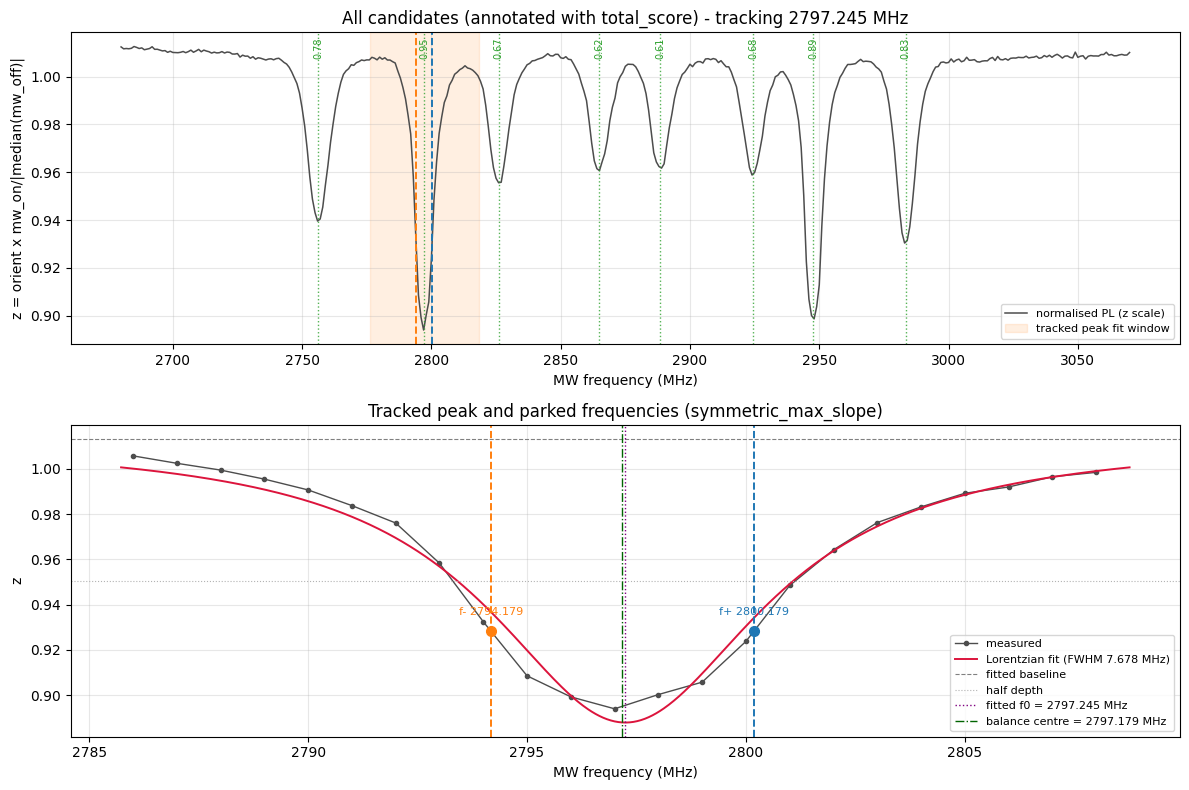

In [8]:
# Step 1b - Place the two parked frequencies and build TWOPOINT_CALIB.
# Consumes CHOSEN_PEAK / z_ref / freqs_mhz from Step 1a; re-runnable on its own after
# changing any knob below.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

if "CHOSEN_PEAK" not in globals():
    raise RuntimeError("Run Step 1a first -- it selects the peak this cell calibrates.")

# Parked-frequency placement on the chosen peak:
#   "symmetric_max_slope"  - empirical max |dz/df| per flank, then symmetrised (default)
#   "symmetric_half_max"   - f0 +/- FWHM/2
#   "lorentzian_max_slope" - f0 +/- gamma/sqrt(3) (analytic Lorentzian max-slope point)
#   "toolkit"              - nv_toolkit _suggest_parked_frequencies (Lockin_module rule)
#   "manual"               - use PARKED_MANUAL_MHZ
PLACEMENT_MODE    = "symmetric_max_slope"
PARKED_MANUAL_MHZ = None        # (f_minus, f_plus) when PLACEMENT_MODE == "manual"
# Slide the pair (keeping its spacing) onto the measured balance point, where the two
# flanks read the same z. That is the true zero of the two-point discriminator; the fitted
# Lorentzian center is generally a few tens of kHz away from it on real, slightly
# asymmetric lines. Ignored for PLACEMENT_MODE == "manual".
BALANCE_PARKED_PAIR = True

# NV gyromagnetic ratio, used only to quote a peak shift as an equivalent field
# projection along the tracked NV axis. This is NOT |B|.
# 28.024 GHz/T = 28.024e-3 MHz/uT, so delta_f[MHz] / this = shift in microtesla.
GAMMA_NV_MHZ_PER_UT = 28.024e-3

# -------------------------------------------------- place the two parked freqs ---
f0 = CHOSEN_PEAK["f0_mhz"]
gamma = CHOSEN_PEAK["gamma_mhz"]
PEAK_WINDOW_HALF_MHZ = max(SLOPE_SEARCH_FWHM * CHOSEN_PEAK["fwhm_mhz"], 3 * _df_step_mhz)
_slopes = flank_max_slopes(freqs_mhz, z_ref, f0, PEAK_WINDOW_HALF_MHZ)

if PLACEMENT_MODE == "manual":
    if PARKED_MANUAL_MHZ is None:
        raise ValueError('PLACEMENT_MODE == "manual" requires PARKED_MANUAL_MHZ = (f_minus, f_plus)')
    f_minus, f_plus = sorted(float(v) for v in PARKED_MANUAL_MHZ)
elif PLACEMENT_MODE == "symmetric_half_max":
    f_minus, f_plus = f0 - gamma, f0 + gamma
elif PLACEMENT_MODE == "lorentzian_max_slope":
    _delta = gamma / np.sqrt(3.0)
    f_minus, f_plus = f0 - _delta, f0 + _delta
elif PLACEMENT_MODE == "symmetric_max_slope":
    _d_minus = abs(f0 - _slopes["minus"][0])
    _d_plus = abs(_slopes["plus"][0] - f0)
    _delta = float(np.nanmean([_d_minus, _d_plus]))
    if not np.isfinite(_delta) or _delta <= 0:
        _delta = gamma / np.sqrt(3.0)
        print("  Empirical max-slope search failed; fell back to gamma/sqrt(3).")
    f_minus, f_plus = f0 - _delta, f0 + _delta
elif PLACEMENT_MODE == "toolkit":
    _plan = _suggest_parked_frequencies(freqs_mhz, measured, np.asarray([f0]), placement="auto")
    f_minus = float(_plan[0].frequency_minus_mhz)
    f_plus = float(_plan[0].frequency_plus_mhz)
else:
    raise ValueError(f"Unknown PLACEMENT_MODE: {PLACEMENT_MODE!r}")

# Slide the pair onto the measured balance point (z equal on both flanks), keeping the
# spacing. Solved by bisection on the sign change of the imbalance, searched within half
# the parked spacing of f0 so it cannot wander onto a neighbouring feature.
BALANCE_OFFSET_MHZ = 0.0
if BALANCE_PARKED_PAIR and PLACEMENT_MODE != "manual":
    _delta = 0.5 * (f_plus - f_minus)
    _cs = np.linspace(f0 - _delta, f0 + _delta, 4001)
    _imb = (np.interp(_cs - _delta, freqs_mhz, z_ref)
            - np.interp(_cs + _delta, freqs_mhz, z_ref))
    _sc = np.flatnonzero(np.sign(_imb[:-1]) != np.sign(_imb[1:]))
    if _sc.size:
        _i = int(_sc[np.argmin(np.abs(_cs[_sc] - f0))])
        _t = _imb[_i] / (_imb[_i] - _imb[_i + 1])
        _c_bal = float(_cs[_i] + _t * (_cs[_i + 1] - _cs[_i]))
        BALANCE_OFFSET_MHZ = _c_bal - f0
        f_minus, f_plus = _c_bal - _delta, _c_bal + _delta
    else:
        print("  Balance point not bracketed within +/- one parked spacing of f0; "
              "leaving the pair centred on the fitted f0.")

# Measured baselines and slopes at the parked points, in the calibration (z) scale.
_grad_z = np.gradient(z_ref, freqs_mhz)
baseline_minus = float(np.interp(f_minus, freqs_mhz, z_ref))
baseline_plus  = float(np.interp(f_plus,  freqs_mhz, z_ref))
slope_minus    = float(np.interp(f_minus, freqs_mhz, _grad_z))
slope_plus     = float(np.interp(f_plus,  freqs_mhz, _grad_z))

TWOPOINT_CALIB = {
    "odmr_csv":              str(ODMR_CSV_FOR_PLAN),
    "orient":                float(Z_ORIENT),
    "f0_mhz":                float(f0),
    "gamma_mhz":             float(gamma),
    "fwhm_mhz":              float(CHOSEN_PEAK["fwhm_mhz"]),
    "contrast":              float(CHOSEN_PEAK["contrast"]),
    "baseline_fit":          float(CHOSEN_PEAK["baseline"]),
    "rms_resid":             float(CHOSEN_PEAK["rms_resid"]),
    "fit_window_mhz":        float(CHOSEN_PEAK["window_mhz"]),
    "f_minus_mhz":           float(f_minus),
    "f_plus_mhz":            float(f_plus),
    "baseline_minus":        baseline_minus,
    "baseline_plus":         baseline_plus,
    "slope_minus_per_mhz":   slope_minus,
    "slope_plus_per_mhz":    slope_plus,
    "placement_mode":        PLACEMENT_MODE,
    "balance_offset_mhz":    float(BALANCE_OFFSET_MHZ),
    "snr":                   float(chosen["snr"]),
    "total_score":           float(chosen["total_score"]),
    "gamma_nv_mhz_per_uT":   float(GAMMA_NV_MHZ_PER_UT),
    # Constant used to put raw live ADC counts on the calibration z scale when no
    # per-shot reference is taken (TWOPOINT_SKIP_REFERENCE). It is exactly the divisor
    # Step 1a used to build spectrum_norm, so both live on the same scale.
    "ref_norm_counts":       float(abs(np.median(_mw_off))),
}

TWOPOINT_FREQS_MHZ = np.asarray([f_minus, f_plus], dtype=float)

# The parked frequencies must straddle f0 with slopes of opposite sign, or neither
# conversion method has a stable inverse.
assert f_minus < f0 < f_plus, (
    f"Parked frequencies must straddle f0: {f_minus:.3f} < {f0:.3f} < {f_plus:.3f} failed"
)
if not (slope_minus < 0 < slope_plus):
    print(f"WARNING: expected slope_minus < 0 < slope_plus in z-space, got "
          f"{slope_minus:+.4g} and {slope_plus:+.4g}. The parked points may be outside the "
          f"dip, or the peak is contaminated by a neighbour.")

# ------------------------------------------------------- conversion helpers ---
# Defined here because they are pure functions of TWOPOINT_CALIB; the maths is documented
# in the Step 3 markdown. Step 3 onwards just calls them.
#
# Only the slope-based estimator is used -- the same expression Lockin_module runs on each
# of its 8 blocks (nv_toolkit.two_point.estimate_delta_f_mhz). An exact Lorentzian
# depth-ratio inversion used to live here too; it was removed because it divides by the
# dip-depth ratio, which is ill-conditioned whenever a flank sits near the baseline, and
# it produced NaNs and multi-MHz spikes on real data while this estimator stayed clean.

def twopoint_z_from_counts(signal_counts, reference_counts=None, calib=None):
    """Raw ADC counts -> calibration-scale z.

    With a per-shot reference, divide by |reference| (not reference) so dips point the
    same way for positive PL and negative homodyne ADC -- the same convention as
    nv_toolkit.two_point.normalised_signal_from_counts, plus the orientation factor.

    With reference_counts=None (TWOPOINT_SKIP_REFERENCE, where the MW cannot truly be
    gated off so an "MW-off" shot is not a clean normaliser) divide by the constant
    captured at calibration time instead. A multiplicative drift in laser power then
    scales z_plus and z_minus together, and since the estimator uses their DIFFERENCE --
    which is ~0 for a balanced pair -- it largely cancels anyway. What does not cancel is
    a constant offset, which is why the live cell auto-zeros.
    """
    calib = TWOPOINT_CALIB if calib is None else calib
    if reference_counts is None:
        norm = float(calib["ref_norm_counts"])
    else:
        norm = np.abs(np.asarray(reference_counts, dtype=float))
        if np.any(norm == 0):
            raise ValueError("reference_counts must be non-zero")
    return float(calib["orient"]) * np.asarray(signal_counts, dtype=float) / norm


def twopoint_delta_f_linear(z_minus, z_plus, calib=None, zero_lockin=None):
    """Slope-based df -- same formula as nv_toolkit.two_point.estimate_delta_f_mhz.

    zero_lockin overrides the reference value of (z_plus - z_minus) that counts as zero
    shift. It defaults to the calibration's (b_plus - b_minus) from the ODMR sweep; the
    live cell passes its auto-zero instead, which is what removes the constant offset
    introduced by dropping the per-shot reference.
    """
    calib = TWOPOINT_CALIB if calib is None else calib
    denom = float(calib["slope_minus_per_mhz"]) - float(calib["slope_plus_per_mhz"])
    if abs(denom) < 1e-12:
        raise ValueError("Calibration slopes are too small for a stable delta_f estimate")
    if zero_lockin is None:
        zero_lockin = float(calib["baseline_plus"]) - float(calib["baseline_minus"])
    d_current = np.asarray(z_plus, dtype=float) - np.asarray(z_minus, dtype=float)
    return (d_current - float(zero_lockin)) / denom


# --------------------------------------------------------------- persist -----
TWOPOINT_DIR = PROJECT_ROOT / "data" / "twopoint_lockin"
TWOPOINT_DIR.mkdir(parents=True, exist_ok=True)
TWOPOINT_CALIB_JSON = TWOPOINT_DIR / f"twopoint_calibration_{ODMR_CSV_FOR_PLAN.stem}.json"
TWOPOINT_CALIB_JSON.write_text(json.dumps(TWOPOINT_CALIB, indent=2), encoding="utf-8")

TWOPOINT_PLAN_CSV = TWOPOINT_DIR / f"twopoint_plan_{ODMR_CSV_FOR_PLAN.stem}.csv"
pd.DataFrame([
    {"point_index": 1, "point_in_block": 0, "label": "f_minus", "frequency_mhz": f_minus,
     "baseline_z": baseline_minus, "slope_z_per_mhz": slope_minus},
    {"point_index": 2, "point_in_block": 1, "label": "f_plus", "frequency_mhz": f_plus,
     "baseline_z": baseline_plus, "slope_z_per_mhz": slope_plus},
]).to_csv(TWOPOINT_PLAN_CSV, index=False)

_denom = slope_minus - slope_plus
print(f"\nTracked peak:  f0 = {f0:.4f} MHz,  FWHM = {CHOSEN_PEAK['fwhm_mhz']:.4f} MHz,  "
      f"contrast = {CHOSEN_PEAK['contrast']:.5f},  SNR = {chosen['snr']:.1f}")
print(f"Fit:           window {CHOSEN_PEAK['window_mhz']:.1f} MHz "
      f"({CHOSEN_PEAK['n_points']} points), residual {CHOSEN_PEAK['rms_resid']:.3e} "
      f"({100 * CHOSEN_PEAK['rms_resid'] / CHOSEN_PEAK['contrast']:.1f}% of depth)")
print(f"Symmetry:      half-widths L/R = {chosen['halfwidth_left_mhz']:.3f} / "
      f"{chosen['halfwidth_right_mhz']:.3f} MHz  (asym {chosen['asym_width']:.3f}), "
      f"slope asym {chosen['asym_slope']:.3f}")
print(f"Placement:     {PLACEMENT_MODE}  ->  f- = {f_minus:.4f} MHz, f+ = {f_plus:.4f} MHz "
      f"(spacing +/-{0.5 * (f_plus - f_minus):.4f} MHz = {0.5*(f_plus-f_minus)/CHOSEN_PEAK['fwhm_mhz']:.2f} FWHM)")
if BALANCE_PARKED_PAIR and PLACEMENT_MODE != "manual":
    print(f"Balance:       pair centred {BALANCE_OFFSET_MHZ*1e3:+.1f} kHz from the fitted f0, "
          f"where both flanks read the same z (residual imbalance "
          f"{baseline_plus - baseline_minus:+.2e})")
print(f"Flank slopes:  m- = {slope_minus:+.5g} /MHz,  m+ = {slope_plus:+.5g} /MHz  "
      f"(denominator m- - m+ = {_denom:+.5g})")
print(f"Linear-method scale: 1e-4 in (z+ - z-) -> {abs(1e-4 / _denom) * 1e3:.2f} kHz of peak shift")
print(f"\nCalibration JSON: {TWOPOINT_CALIB_JSON}")
print(f"Parked plan CSV:  {TWOPOINT_PLAN_CSV}")
display(FileLink(str(TWOPOINT_CALIB_JSON)))

# ------------------------------------------------------------------ plots ----
fig, (ax_all, ax_zoom) = plt.subplots(2, 1, figsize=(12, 8))

ax_all.plot(freqs_mhz, z_ref, color="0.3", lw=1.1, label="normalised PL (z scale)")
for _, r in df_scores.iterrows():
    _c = "tab:green" if r["eligible"] else "0.6"
    ax_all.axvline(r["center_mhz"], color=_c, ls=":", lw=1.0, alpha=0.8)
    ax_all.annotate(f"{r['total_score']:.2f}", xy=(r["center_mhz"], 1.0),
                    xycoords=("data", "axes fraction"),
                    xytext=(0, -4), textcoords="offset points", ha="center", va="top",
                    fontsize=7, color=_c, rotation=90)
ax_all.axvspan(f0 - CHOSEN_PEAK["window_mhz"] / 2, f0 + CHOSEN_PEAK["window_mhz"] / 2,
               color="tab:orange", alpha=0.12, label="tracked peak fit window")
ax_all.axvline(f_minus, color="tab:orange", ls="--", lw=1.4)
ax_all.axvline(f_plus,  color="tab:blue",   ls="--", lw=1.4)
ax_all.set(xlabel="MW frequency (MHz)", ylabel="z = orient x mw_on/|median(mw_off)|",
           title=f"All candidates (annotated with total_score) - tracking {f0:.3f} MHz")
ax_all.grid(True, alpha=0.3)
ax_all.legend(fontsize=8, loc="lower right")

_zoom_half = max(1.5 * CHOSEN_PEAK["fwhm_mhz"], 1.5 * (f_plus - f_minus))
_m = np.abs(freqs_mhz - f0) <= _zoom_half
_ffine = np.linspace(f0 - _zoom_half, f0 + _zoom_half, 800)
ax_zoom.plot(freqs_mhz[_m], z_ref[_m], "o-", ms=3, lw=1.0, color="0.3", label="measured")
ax_zoom.plot(_ffine, lorentzian_dip(_ffine, CHOSEN_PEAK["baseline"], CHOSEN_PEAK["contrast"],
                                    f0, gamma),
             color="crimson", lw=1.4,
             label=f"Lorentzian fit (FWHM {CHOSEN_PEAK['fwhm_mhz']:.3f} MHz)")
ax_zoom.axhline(CHOSEN_PEAK["baseline"], color="0.5", ls="--", lw=0.8, label="fitted baseline")
ax_zoom.axhline(CHOSEN_PEAK["baseline"] - 0.5 * CHOSEN_PEAK["contrast"], color="0.7", ls=":", lw=0.8,
                label="half depth")
ax_zoom.axvline(f0, color="purple", ls=":", lw=1.0, label=f"fitted f0 = {f0:.3f} MHz")
_c_mid = 0.5 * (f_minus + f_plus)
if abs(_c_mid - f0) > 1e-9:
    ax_zoom.axvline(_c_mid, color="darkgreen", ls="-.", lw=1.0,
                    label=f"balance centre = {_c_mid:.3f} MHz")
for _f, _b, _col, _lab in ((f_minus, baseline_minus, "tab:orange", "f-"),
                           (f_plus,  baseline_plus,  "tab:blue",   "f+")):
    ax_zoom.axvline(_f, color=_col, ls="--", lw=1.4)
    ax_zoom.plot([_f], [_b], "o", color=_col, ms=7, zorder=5)
    ax_zoom.annotate(f"{_lab} {_f:.3f}", xy=(_f, _b), xytext=(0, 12), textcoords="offset points",
                     ha="center", fontsize=8, color=_col)
ax_zoom.set(xlabel="MW frequency (MHz)", ylabel="z",
            title=f"Tracked peak and parked frequencies ({PLACEMENT_MODE})")
ax_zoom.grid(True, alpha=0.3)
ax_zoom.legend(fontsize=8, loc="lower right")

plt.tight_layout()
plt.show()

## Step 2 - One batch at the two parked frequencies

`MultipointLockinODMR` is generic in the number of frequencies, so the same single-program
upload used for 16 points works for 2. With only 2 points a batch is roughly 8x shorter
than the 16-point equivalent at the same `reps`, which is the whole reason for running a
single peak: the same averaging in an eighth of the time, or 8x the update rate at the
same noise.

This cell is the sanity check before going live - it confirms the parked ADC values land
on the ODMR flanks where Step 1 said they would.

Built single MultipointLockinODMR program for 2 frequencies (2794.179, 2800.179 MHz) in 0.00 s
Predicted time per batch: 2 ms (0.2 ms/rep x 10 reps)
Reference readout: SKIPPED (1 readout per frequency) -> 2 readouts per rep
batch 1/1: acquired in 14 ms (predicted ~2 ms)

Saved 1 batches to C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_collected.csv


,batch,time_s,timestamp_epoch_s,acq_seconds,peak_01,peak_01_freq_mhz,peak_02,peak_02_freq_mhz
0,0,0.013932,1.786995e+09,0.013746,1313.397784,2794.178625,1315.784996,2800.178623


C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_collected.csv

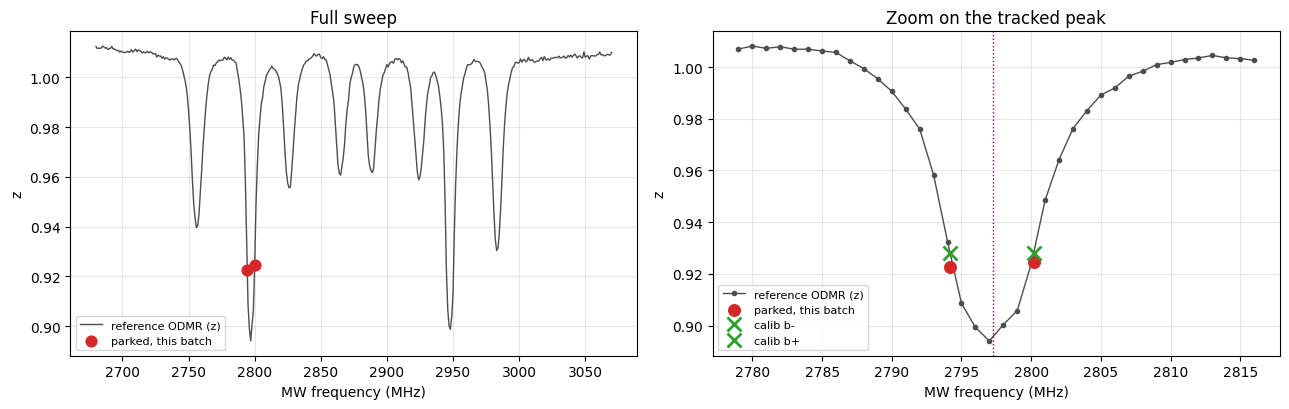

Parked z vs calibration baseline:  f- -0.00549   f+ -0.00381
Both offsets should be small and of comparable size. A large COMMON offset means the laser/MW level drifted since the ODMR sweep (harmless for the exact method, which cancels contrast, but it biases the linear method). A large DIFFERENTIAL offset is a genuine peak shift.


In [10]:
# Step 2 - Acquire the two parked frequencies in ONE FPGA program upload.
#
# DEFENSIVE GUARD (inherited from Lockin_module): the program is built ONCE before the
# batch loop. Each MultipointLockinODMR build is a ~300-500 ms FPGA upload, so rebuilding
# inside the loop is what made the old 8-peak cell take minutes.
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time
import numpy as np
import pandas as pd
from IPython.display import FileLink, display

# notebook_modules/ is already on sys.path via the project_root_setup cell.
import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

if "TWOPOINT_FREQS_MHZ" not in globals():
    raise RuntimeError("Run Step 1 first -- it defines TWOPOINT_FREQS_MHZ and TWOPOINT_CALIB.")

# --- Acquisition parameters ---
TWOPOINT_REPS_PER_BATCH   = 10
TWOPOINT_N_BATCHES        = 1
TWOPOINT_OFF_RESONANCE_MHZ = 2700.0   # only used when TWOPOINT_SKIP_REFERENCE is False
TWOPOINT_RELAX_DELAY_TREG  = 1000     # laser repolarisation window inside each frequency block
# Drop the per-frequency reference readout. The MW cannot actually be gated off, so an
# "MW-off" shot is a contaminated copy of the signal rather than a clean normaliser --
# and taking it doubles the readouts per rep. With it skipped, z is formed against the
# constant TWOPOINT_CALIB["ref_norm_counts"] captured from the reference ODMR sweep.
TWOPOINT_SKIP_REFERENCE    = True
TWOPOINT_DATA_CSV = TWOPOINT_DIR / "twopoint_lockin_collected.csv"
TWOPOINT_DATA_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the two-point config ---
cfg = copy(default_config)
cfg.multipoint_freqs_mhz = list(TWOPOINT_FREQS_MHZ)
cfg.odmr_reference_offres_mhz = TWOPOINT_OFF_RESONANCE_MHZ
cfg.multipoint_skip_reference = bool(TWOPOINT_SKIP_REFERENCE)
cfg.relax_delay_treg = int(TWOPOINT_RELAX_DELAY_TREG)
# QickSweep needs a sweep definition even though we drive frequencies from body();
# a zero-span single point keeps the outer sweep trivial.
cfg.mw_start_fMHz = float(TWOPOINT_FREQS_MHZ[0])
cfg.mw_end_fMHz = float(TWOPOINT_FREQS_MHZ[0])
cfg.nsweep_points = 1
cfg.reps = int(TWOPOINT_REPS_PER_BATCH)
cfg.pre_init = getattr(default_config, "pre_init", True)

t_build_start = perf_counter()
prog = MultipointLockinODMR(cfg)
_build_seconds = perf_counter() - t_build_start
_predicted_ms_per_batch = prog.total_time() * 1e3
print(f"Built single MultipointLockinODMR program for {len(TWOPOINT_FREQS_MHZ)} frequencies "
      f"({TWOPOINT_FREQS_MHZ[0]:.3f}, {TWOPOINT_FREQS_MHZ[1]:.3f} MHz) in {_build_seconds:.2f} s")
print(f"Predicted time per batch: {_predicted_ms_per_batch:.0f} ms "
      f"({prog.time_per_rep()*1e3:.1f} ms/rep x {cfg.reps} reps)")
print(f"Reference readout: {'SKIPPED (1 readout per frequency)' if TWOPOINT_SKIP_REFERENCE else 'taken (2 readouts per frequency)'}"
      f" -> {len(TWOPOINT_FREQS_MHZ) * (1 if TWOPOINT_SKIP_REFERENCE else 2)} readouts per rep")

_first_batch_dt = None
rows = []
t0 = perf_counter()
for batch in range(int(TWOPOINT_N_BATCHES)):
    t_acq_start = perf_counter()
    d_batch = prog.acquire(progress=False)
    acq_dt = perf_counter() - t_acq_start
    if _first_batch_dt is None:
        _first_batch_dt = acq_dt

    row = {
        "batch": batch,
        "time_s": perf_counter() - t0,
        "timestamp_epoch_s": time(),
        "acq_seconds": acq_dt,
    }
    _refs = d_batch.reference if d_batch.reference is not None else [None] * len(d_batch.signal)
    for k, (freq_mhz, sig, ref) in enumerate(zip(d_batch.frequencies_mhz, d_batch.signal, _refs)):
        row[f"peak_{k+1:02d}"] = float(sig)
        if ref is not None:
            row[f"peak_{k+1:02d}_ref"] = float(ref)
        row[f"peak_{k+1:02d}_freq_mhz"] = float(freq_mhz)
    rows.append(row)
    print(f"batch {batch+1}/{int(TWOPOINT_N_BATCHES)}: acquired in {acq_dt*1000:.0f} ms "
          f"(predicted ~{_predicted_ms_per_batch:.0f} ms)")

df_twopoint = pd.DataFrame(rows)
df_twopoint.to_csv(TWOPOINT_DATA_CSV, index=False)
print(f"\nSaved {len(df_twopoint)} batches to {TWOPOINT_DATA_CSV}")

if _first_batch_dt * 1000 > _predicted_ms_per_batch * 5:
    print(f"WARNING: first batch took {_first_batch_dt*1000:.0f} ms vs predicted "
          f"{_predicted_ms_per_batch:.0f} ms. If this persists across runs, network/board "
          f"state is the likely cause.")

display(df_twopoint)
display(FileLink(str(TWOPOINT_DATA_CSV)))

# --- Overlay: do the parked ADC values land on the ODMR flanks? ---
_row = df_twopoint.iloc[0]
_pk_f = np.array([float(_row["peak_01_freq_mhz"]), float(_row["peak_02_freq_mhz"])])
_pk_s = np.array([float(_row["peak_01"]), float(_row["peak_02"])])
if "peak_01_ref" in df_twopoint.columns:
    _pk_r = np.array([float(_row["peak_01_ref"]), float(_row["peak_02_ref"])])
    _pk_z = TWOPOINT_CALIB["orient"] * _pk_s / np.abs(_pk_r)
else:
    _pk_z = TWOPOINT_CALIB["orient"] * _pk_s / float(TWOPOINT_CALIB["ref_norm_counts"])

_zoom_half = max(2.5 * TWOPOINT_CALIB["fwhm_mhz"], 1.5 * (TWOPOINT_CALIB["f_plus_mhz"] - TWOPOINT_CALIB["f_minus_mhz"]))
_m = np.abs(freqs_mhz - TWOPOINT_CALIB["f0_mhz"]) <= _zoom_half

fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(13, 4.2))
ax_l.plot(freqs_mhz, TWOPOINT_CALIB["orient"] * spectrum_norm, color="0.3", lw=1.0,
          label="reference ODMR (z)")
ax_l.scatter(_pk_f, _pk_z, color="tab:red", s=60, zorder=5, label="parked, this batch")
ax_l.set(xlabel="MW frequency (MHz)", ylabel="z", title="Full sweep")
ax_l.grid(True, alpha=0.3); ax_l.legend(fontsize=8)

ax_r.plot(freqs_mhz[_m], (TWOPOINT_CALIB["orient"] * spectrum_norm)[_m], "o-", ms=3, lw=1.0,
          color="0.3", label="reference ODMR (z)")
ax_r.scatter(_pk_f, _pk_z, color="tab:red", s=70, zorder=5, label="parked, this batch")
for _f, _b, _lab in ((TWOPOINT_CALIB["f_minus_mhz"], TWOPOINT_CALIB["baseline_minus"], "calib b-"),
                     (TWOPOINT_CALIB["f_plus_mhz"],  TWOPOINT_CALIB["baseline_plus"],  "calib b+")):
    ax_r.plot([_f], [_b], "x", color="tab:green", ms=10, mew=2, zorder=6, label=_lab)
ax_r.axvline(TWOPOINT_CALIB["f0_mhz"], color="purple", ls=":", lw=1.0)
ax_r.set(xlabel="MW frequency (MHz)", ylabel="z", title="Zoom on the tracked peak")
ax_r.grid(True, alpha=0.3); ax_r.legend(fontsize=8)
plt.tight_layout()
plt.show()

_dz = _pk_z - np.array([TWOPOINT_CALIB["baseline_minus"], TWOPOINT_CALIB["baseline_plus"]])
print(f"Parked z vs calibration baseline:  f- {_dz[0]:+.5f}   f+ {_dz[1]:+.5f}")
print("Both offsets should be small and of comparable size. A large COMMON offset means "
      "the laser/MW level drifted since the ODMR sweep (harmless for the exact method, "
      "which cancels contrast, but it biases the linear method). A large DIFFERENTIAL "
      "offset is a genuine peak shift.")

## Step 3 - Two-point conversion: parked PL -> peak frequency

One estimator, the same one `Lockin_module.ipynb` runs on each of its 8 blocks
(`nv_toolkit.two_point.estimate_delta_f_mhz`). Working in the normalised,
orientation-corrected signal `z = orient x (signal / |reference|)`:

`df = [(z_plus - z_minus) - (b_plus - b_minus)] / (m_minus - m_plus)`

where `b` are the calibration baselines and `m` the flank slopes, both measured off the
reference ODMR sweep in Step 1b. It is zero by construction when the parked pair reads what
the sweep read, it cannot produce a NaN, and its noise is exactly
`sigma(z_plus - z_minus) / |m_minus - m_plus|` - linear in the measurement noise, with no
term that can blow up.

The shift is valid while it stays small compared to the linewidth. Past roughly half the
FWHM the flanks are no longer locally linear and the estimate compresses; Step 5 prints the
range as a percentage of the FWHM so you can see when that happens.

**Removed:** an exact Lorentzian depth-ratio inversion used to run alongside this as
"method A", carried over from the QDM-heart notebook. It inverts `d_minus / d_plus`, so it
divides by the dip depth at a parked point. On real data a flank sitting near the baseline
made that denominator straddle zero, which produced multi-MHz spikes and NaN gaps in the
peak-shift trace while this estimator stayed clean. `Lockin_module` never used it, and
neither does this notebook now.

`B_shift_uT` is `df / 28.024e-3 MHz/uT` - the field change projected on the tracked NV
axis, assuming the shift is Zeeman in origin. It is not `|B|`, and a temperature drift in
`D` would appear here too.

In [11]:
# Step 3 - Apply the two-point conversion to the Step 2 batch.
# twopoint_z_from_counts / twopoint_delta_f_linear are defined at the end of Step 1b (they
# are pure functions of TWOPOINT_CALIB); the maths is in the markdown above. Everything
# works in z = orient * signal / |reference|.
import numpy as np
import pandas as pd
from IPython.display import display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b first -- it defines TWOPOINT_CALIB and the conversion helpers.")
if "df_twopoint" not in globals():
    raise RuntimeError("Run Step 2 first -- it defines df_twopoint.")


def twopoint_rows_from_wide(df_wide, calib=None):
    """Wide peak_01/peak_02 frame -> per-batch peak-shift table.

    delta_f is referenced to the calibration state by construction: it is zero when the
    parked pair reads the same (b_plus - b_minus) the reference ODMR sweep did.
    """
    calib = TWOPOINT_CALIB if calib is None else calib
    # Reference columns are absent when the run skipped the reference readout; then z is
    # formed against the constant calib["ref_norm_counts"] instead.
    _r1 = df_wide["peak_01_ref"].to_numpy(float) if "peak_01_ref" in df_wide.columns else None
    _r2 = df_wide["peak_02_ref"].to_numpy(float) if "peak_02_ref" in df_wide.columns else None
    z_minus = twopoint_z_from_counts(df_wide["peak_01"].to_numpy(float), _r1, calib)
    z_plus = twopoint_z_from_counts(df_wide["peak_02"].to_numpy(float), _r2, calib)
    delta_f = twopoint_delta_f_linear(z_minus, z_plus, calib)
    out = pd.DataFrame({
        "batch":          df_wide["batch"].to_numpy() if "batch" in df_wide else np.arange(len(df_wide)),
        "time_s":         df_wide["time_s"].to_numpy(float) if "time_s" in df_wide else np.arange(len(df_wide), dtype=float),
        "z_minus":        z_minus,
        "z_plus":         z_plus,
        "lockin_signal":  z_plus - z_minus,
        "delta_f_mhz":    delta_f,
        "peak_shift_kHz": delta_f * 1e3,
        "f_new_mhz":      float(calib["f0_mhz"]) + delta_f,
        "B_shift_uT":     delta_f / float(calib["gamma_nv_mhz_per_uT"]),
    })
    return out


df_convert = twopoint_rows_from_wide(df_twopoint)
TWOPOINT_CONVERT_CSV = TWOPOINT_DATA_CSV.with_name("twopoint_lockin_peak_inference.csv")
df_convert.to_csv(TWOPOINT_CONVERT_CSV, index=False)

print(f"Tracked peak: f0 = {TWOPOINT_CALIB['f0_mhz']:.4f} MHz, "
      f"FWHM = {TWOPOINT_CALIB['fwhm_mhz']:.4f} MHz")
if "peak_01_ref" not in df_twopoint.columns:
    print("No per-shot reference in this batch, so z is formed against the constant "
          "ref_norm_counts. Expect a CONSTANT offset here -- the absolute PL level has moved "
          "since the sweep. Step 4's auto-zero removes it; this single-batch number is only "
          "meaningful as a sanity check that the parked points sit on the flanks.")
display(df_convert.round(6))
print(f"\nWrote {TWOPOINT_CONVERT_CSV}")

_last = df_convert.iloc[-1]
_fwhm_khz = TWOPOINT_CALIB["fwhm_mhz"] * 1e3
print(f"\nLatest batch: f_new = {_last['f_new_mhz']:.4f} MHz  "
      f"(shift {_last['peak_shift_kHz']:+.1f} kHz = {_last['B_shift_uT']:+.2f} uT along this NV axis, "
      f"{100 * abs(_last['peak_shift_kHz']) / _fwhm_khz:.1f}% of the linewidth)")
if abs(_last["peak_shift_kHz"]) > 0.5 * _fwhm_khz:
    print("The shift exceeds half the linewidth, which is past the linear range of this "
          "estimator -- re-run Steps 1a/1b so the parked pair straddles the peak again.")

Tracked peak: f0 = 2797.2449 MHz, FWHM = 7.6784 MHz
No per-shot reference in this batch, so z is formed against the constant ref_norm_counts. Expect a CONSTANT offset here -- the absolute PL level has moved since the sweep. Step 4's auto-zero removes it; this single-batch number is only meaningful as a sanity check that the parked points sit on the flanks.


,batch,time_s,z_minus,z_plus,lockin_signal,delta_f_mhz,peak_shift_kHz,f_new_mhz,B_shift_uT
0,0,0.013932,0.922735,0.924412,0.001677,-0.037698,-37.698207,2797.207244,-1.345212



Wrote C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_peak_inference.csv

Latest batch: f_new = 2797.2072 MHz  (shift -37.7 kHz = -1.35 uT along this NV axis, 0.5% of the linewidth)


## Step 4 - Live continuous peak tracking

Keeps acquiring batch after batch and converts each one to a peak frequency on the fly,
streaming to CSV. This is the two-point equivalent of `lockin_live` in
`Lockin_module.ipynb`, and it carries over the same two fixes from there:

* **Peaking transient.** `pre_init=True` fires an MW polarisation pulse at every batch
  boundary, which perturbs the spins and produces a per-batch transient. The live program
  is built with `pre_init=False` and primed once with a throwaway `pre_init=True` acquire.
  An assertion enforces this.
* **Spike rejection.** A causal Hampel filter on the raw ADC (2 channels here instead of
  16) replaces single-batch glitches with the rolling per-channel median. Both the raw and
  the despiked values are recorded; `peak_NN_spike_*` flags mark every replacement.

`peak_shift_kHz` in the CSV is always referenced to `f0_ref_exact_mhz`, the Step 1
calibration zero shared by both methods - an absolute number that does not depend on when
the run started. Step 5 can re-reference to the run's first sample or its mean without
re-acquiring.

2 freqs, order=forward (2 slots/rep), tau=120.0 us, 500 reps -> 240 us/rep, 120.00 ms FPGA + 1.6 ms host -> 8.2 Hz
tProc force-stop per acquire: True (burst-mode default)
Reference readout: SKIPPED (1 readout/frequency)
Mode: BURST -- 500 samples per acquire
Built LIVE program (pre_init=False) for 2 freqs (2794.168, 2800.168 MHz), 500 reps/batch, predicted ~120 ms/batch FPGA work
Watchdog: will warn if any batch exceeds 360 ms.
Priming spin polarization (one acquire with pre_init=True)...
Priming done. Entering live loop.

Spike rejection: enabled=False, window=11, k_sigma=4, warmup=4, sigma_floor=1.5, baseline=(none)

Auto-zero over 20 batches: (z+ - z-) zero = +2.408794e-03 (sweep said +7.771561e-16)
  -> removes a constant -41 kHz offset. Shifts are now measured from the start of this run, not from the ODMR sweep.

Live stopped by user -- 63 batches collected.

Live run finished: 31500 samples from 63 acquire calls in 4.5 s (6948.0 Hz effective sample rate, 13.9 Hz acquire rate)
  b

C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_live_20260817_142804.csv


Per-batch timing (ms): predicted ~120  actual median=15, p95=136, max=136
Watchdog never fired -- runtime is consistent with prediction.
Data freshness: all 63 acquires returned new data.

Calibration validity - dip depth at the parked points:
  f-: calibrated 0.09376   measured 0.08981 +/- 0.00583   (96% of calibrated, depth/noise = 15.4)
  f+: calibrated 0.09376   measured 0.08837 +/- 0.00574   (94% of calibrated, depth/noise = 15.4)

Peak shift vs calibration f0: mean +16.6 kHz, std 127.0 kHz, pk-pk 907.2 kHz
Equivalent field along this NV axis: std 4.532 uT, pk-pk 32.373 uT


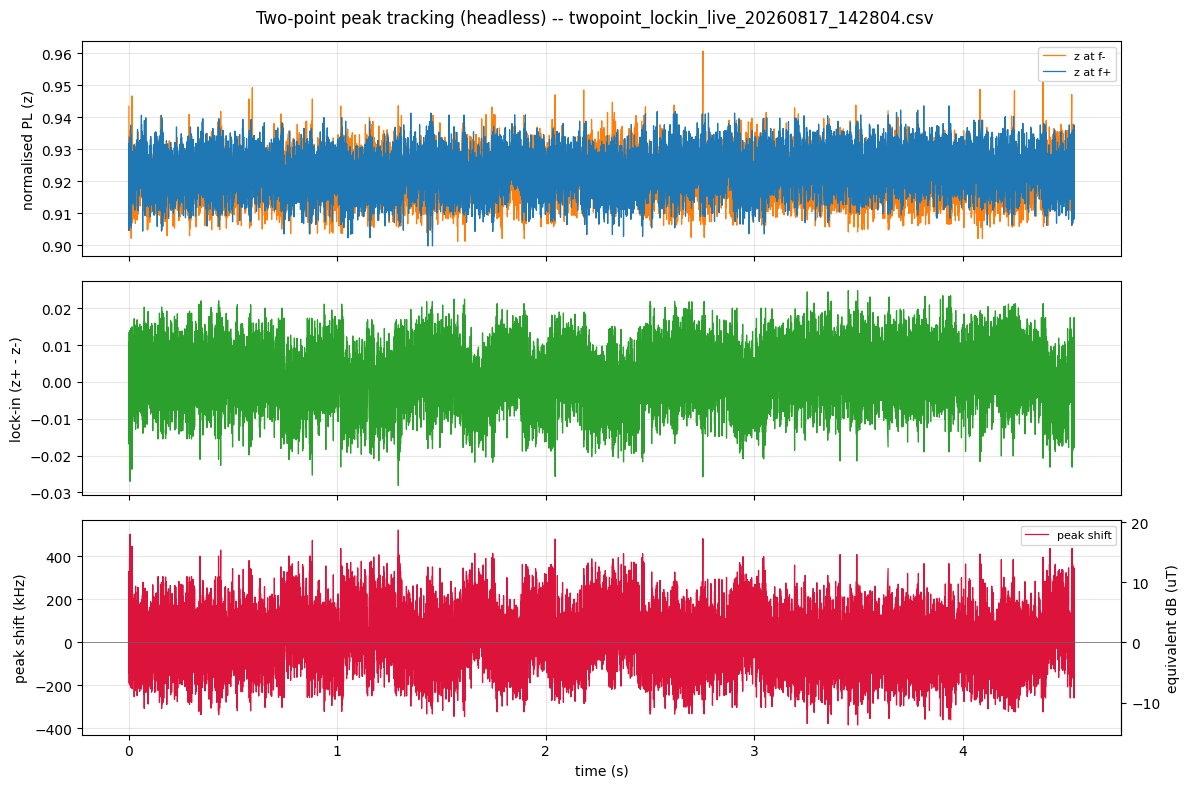

In [32]:
# Step 4 - Live continuous two-point peak tracking.
#
# DEFENSIVE GUARDS (inherited from Lockin_module lockin_live):
#   - assert pre_init=False on the live program (peaking guard)
#   - the program is built BEFORE the loop, never inside it (runtime guard)
#   - watchdog that warns if a batch takes > LIVE_WATCHDOG_FACTOR x predicted time
#   - end-of-run summary with median/p95 batch times so drift is visible
import sys
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b once before live mode -- it defines TWOPOINT_CALIB and "
                       "the conversion helpers.")

import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

import spike_rejection
spike_rejection = importlib.reload(spike_rejection)
from spike_rejection import HampelDespiker

# --- Live-mode parameters ---
# Reps inside each acquire(). The batch time is FPGA-bound, not host-bound -- the
# opposite of what this comment used to claim. Measured on 2026-08-06 at 23 reps and
# tau = 213 us: 11.37 ms per batch, of which 9.77 ms (86%) is the two ADC integration
# windows and only ~1.6 ms is host round-trip. Python outside acquire() costs 0.047 ms.
# So FPGA work is NOT free, and reps trade against rate one for one:
#
#     period ~= reps * n_freqs * tau + 1.6 ms
#
# 23 reps at tau = 120 us gives ~140 Hz. Raising reps further buys little: the noise is
# white only above ~10 Hz, so averaging 23 reps already delivers 1/2.9 rather than the
# ideal 1/4.8, and past ~30 reps the curve is nearly flat (analysis section 3.2).
LIVE_REPS_PER_BATCH     = 10
LIVE_DURATION_SEC       = 30     # set None to run until the Interrupt button
LIVE_PLOT_REFRESH_EVERY = 10     # redraw every N batches. The 3-panel redraw costs ~20 ms
                                 # headless and 50-100 ms once the notebook re-encodes the PNG
                                 # and pushes it to the browser. With 16 parked points that hid
                                 # under ~78 ms of FPGA work; with 2 points the acquire is only
                                 # ~10 ms, so redrawing every batch makes plotting ~90% of the
                                 # loop and throws away the 8x speedup. Set 1 only to debug.
LIVE_SHOW_PLOT          = False   # False = headless; one static figure at the end
LIVE_OFF_RESONANCE_MHZ  = TWOPOINT_OFF_RESONANCE_MHZ if "TWOPOINT_OFF_RESONANCE_MHZ" in globals() else 2700.0
LIVE_RELAX_DELAY_TREG   = 1000   # laser repolarisation window inside each frequency block
LIVE_WATCHDOG_FACTOR    = 3.0
# Order the parked pair is visited inside one rep.
#   "forward" -> A B      the two points are measured one readout window apart, always
#                         in the same direction, so drift in the common PL level enters
#                         their difference to first order.
#   "abba"    -> A B B A  folding slot 0 with slot 3 and slot 1 with slot 2 cancels that
#                         linear drift exactly. It doubles the readouts per rep, so one
#                         abba rep costs and averages exactly two forward reps -- the
#                         cancellation is free, paid in rep count rather than in time.
# Worth having: during the 2026-08-06 heat-gun test the common mode swung 13%
# peak-to-peak while the difference stayed flat, i.e. this term is real and large.
LIVE_PAIR_ORDER         = "forward"

# --- Burst mode: trade the one-sample-per-acquire model for bandwidth ---
# loop_dims = [reps, ...], so every rep is ALREADY an independent time sample about
# time_per_rep() apart; the default path just averages them away. Burst mode keeps the
# rep axis, so one acquire() returns LIVE_BURST_REPS samples and the host overhead is
# paid once per BURST instead of once per sample.
#
# WARNING -- burst mode was silently broken before 2026-08-12. Because the tProc was
# never stopped between runs, the accumulated buffer was read before the new run had
# refilled it: acquires alternated ~13 ms / ~425 ms and every second batch was 95.7%
# bit-identical to the one before. Half of every burst run was a replay, the recorded
# 4.4 kHz was really 2.1 kHz, and row 0 of each stale batch carried a +1908 kHz
# (+68 uT) artefact once per ~0.45 s -- the "periodic noise" in Burst Mode.png.
#
# LIVE_RESET_TPROC below is the fix. The freshness guard in MultipointLockinODMR will
# report any batch that still comes back as a duplicate; check prog_live.n_stale_acquires
# at the end of a run and treat anything above zero as burst mode still being unsafe.
# For sustained high rates prefer the streaming path (analysis section 4.4) -- it needs
# no per-batch reconfiguration and so cannot hit this race at all.
LIVE_BURST_MODE         = True
LIVE_BURST_REPS         = 500    # reps (= time samples) per burst when burst mode is on
# Force-stop the tProc before each acquire. Costs tens of ms per call, which is
# irrelevant next to a 200-400 ms burst but would halve the rate in averaged mode --
# so it defaults to following LIVE_BURST_MODE.
LIVE_RESET_TPROC        = None   # None = auto (on in burst mode, off in averaged mode)
# Skip the per-frequency reference readout: halves the readouts per rep (~2x faster).
LIVE_SKIP_REFERENCE     = TWOPOINT_SKIP_REFERENCE if "TWOPOINT_SKIP_REFERENCE" in globals() else True
# Without a per-shot reference the zero of (z+ - z-) no longer matches the ODMR sweep's
# (b+ - b-): the absolute PL level has moved, and the two readout slots carry a ~1%
# systematic the reference used to divide out. Re-zero on the run itself instead. The
# trade is that the shift is then measured from the START OF THE RUN, not from the sweep.
LIVE_AUTOZERO           = True
LIVE_AUTOZERO_BATCHES   = 20

# --- Spike rejection (causal Hampel filter on raw ADC, 2 channels) ---
LIVE_DESPIKE_ENABLED     = False
LIVE_DESPIKE_WINDOW      = 11    # trailing samples kept per channel
LIVE_DESPIKE_K_SIGMA     = 4     # rejection threshold in MAD-sigma units
LIVE_DESPIKE_WARMUP      = 4     # batches before rejection becomes active
LIVE_DESPIKE_SIGMA_FLOOR = 1.5   # minimum sigma estimate (ADC counts)
LIVE_DESPIKE_SIGMA_CAP   = 2     # maximum sigma estimate (ADC counts)

N_CHANNELS = 2

_run_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
LIVE_CSV = TWOPOINT_DIR / f"twopoint_lockin_live_{_run_stamp}.csv"
LIVE_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the LIVE program with pre_init = False ---
cfg_live = copy(default_config)
cfg_live.multipoint_freqs_mhz      = list(TWOPOINT_FREQS_MHZ)
cfg_live.odmr_reference_offres_mhz = LIVE_OFF_RESONANCE_MHZ
cfg_live.multipoint_skip_reference = bool(LIVE_SKIP_REFERENCE)
cfg_live.multipoint_pair_order     = str(LIVE_PAIR_ORDER)
cfg_live.multipoint_on_stale       = "warn"
cfg_live.relax_delay_treg          = int(LIVE_RELAX_DELAY_TREG)
cfg_live.mw_start_fMHz             = float(TWOPOINT_FREQS_MHZ[0])
cfg_live.mw_end_fMHz               = float(TWOPOINT_FREQS_MHZ[0])
cfg_live.nsweep_points             = 1
cfg_live.reps                      = int(LIVE_BURST_REPS if LIVE_BURST_MODE else LIVE_REPS_PER_BATCH)
cfg_live.pre_init                  = False

assert cfg_live.pre_init is False, (
    "Live mode requires pre_init=False to prevent per-batch peaking. An MW polarization "
    "pulse at start_freq before the body loop perturbs spins toward |+-1> at every batch "
    "boundary; with always-on laser the in-body readout windows then have to re-polarize, "
    "producing a transient."
)

_LIVE_RESET_TPROC = bool(LIVE_BURST_MODE) if LIVE_RESET_TPROC is None else bool(LIVE_RESET_TPROC)

prog_live = MultipointLockinODMR(cfg_live)
_predicted_ms_per_batch = prog_live.total_time() * 1e3

# Print the achievable rate BEFORE running. The readout window dominates the batch time,
# so it is easy to pick an operating point that quietly costs half the rate.
print(prog_live.describe_timing())
print(f"tProc force-stop per acquire: {_LIVE_RESET_TPROC} "
      f"({'burst-mode default' if LIVE_RESET_TPROC is None else 'set explicitly'})")
print(f"Reference readout: {'SKIPPED (1 readout/frequency)' if LIVE_SKIP_REFERENCE else 'taken (2 readouts/frequency)'}")
print(f"Mode: {'BURST -- ' + str(LIVE_BURST_REPS) + ' samples per acquire' if LIVE_BURST_MODE else 'averaged -- 1 sample per acquire'}")
print(f"Built LIVE program (pre_init=False) for {len(TWOPOINT_FREQS_MHZ)} freqs "
      f"({TWOPOINT_FREQS_MHZ[0]:.3f}, {TWOPOINT_FREQS_MHZ[1]:.3f} MHz), "
      f"{cfg_live.reps} reps/batch, predicted ~{_predicted_ms_per_batch:.0f} ms/batch FPGA work")
print(f"Watchdog: will warn if any batch exceeds {_predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR:.0f} ms.")

# --- One-shot priming acquire with pre_init=True (results discarded) ---
cfg_prime = copy(cfg_live)
cfg_prime.pre_init = True
prog_prime = MultipointLockinODMR(cfg_prime)
print("Priming spin polarization (one acquire with pre_init=True)...")
_ = prog_prime.acquire(progress=False)
del prog_prime, cfg_prime
print("Priming done. Entering live loop.\n")

# --- Despiker warm-up baseline from the Step 2 single batch, if available ---
_sig_baseline = None
_ref_baseline = None
_baseline_src = "(none)"
if LIVE_DESPIKE_ENABLED:
    try:
        _bl_row = pd.read_csv(TWOPOINT_DATA_CSV).iloc[-1]
        _sig_baseline = np.array([float(_bl_row[f"peak_{i:02d}"])     for i in range(1, N_CHANNELS + 1)])
        _ref_baseline = (None if LIVE_SKIP_REFERENCE else
                         np.array([float(_bl_row[f"peak_{i:02d}_ref"]) for i in range(1, N_CHANNELS + 1)]))
        _baseline_src = str(TWOPOINT_DATA_CSV)
    except Exception as _e:
        print(f"  (despike) no single-batch baseline available ({_e}); warm-up will pass samples through.")

_despike_kwargs = dict(
    n_channels=N_CHANNELS,
    window=LIVE_DESPIKE_WINDOW,
    k_sigma=LIVE_DESPIKE_K_SIGMA,
    min_warmup=LIVE_DESPIKE_WARMUP,
    sigma_floor=LIVE_DESPIKE_SIGMA_FLOOR,
    sigma_cap=LIVE_DESPIKE_SIGMA_CAP,
)
despiker_sig = HampelDespiker(baseline=_sig_baseline, **_despike_kwargs)
despiker_ref = HampelDespiker(baseline=_ref_baseline, **_despike_kwargs)
print(f"Spike rejection: enabled={LIVE_DESPIKE_ENABLED}, window={LIVE_DESPIKE_WINDOW}, "
      f"k_sigma={LIVE_DESPIKE_K_SIGMA}, warmup={LIVE_DESPIKE_WARMUP}, "
      f"sigma_floor={LIVE_DESPIKE_SIGMA_FLOOR}, baseline={_baseline_src}\n")

# --- Live plot: parked z / lock-in signal / peak shift ---
_gamma_nv = float(TWOPOINT_CALIB["gamma_nv_mhz_per_uT"])   # MHz per microtesla
if LIVE_SHOW_PLOT:
    plt.ion()
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    _l_zminus, = axes[0].plot([], [], "-", lw=1.0, color="tab:orange",
                              label=f"z at f- ({TWOPOINT_CALIB['f_minus_mhz']:.3f} MHz)")
    _l_zplus,  = axes[0].plot([], [], "-", lw=1.0, color="tab:blue",
                              label=f"z at f+ ({TWOPOINT_CALIB['f_plus_mhz']:.3f} MHz)")
    axes[0].axhline(TWOPOINT_CALIB["baseline_minus"], color="tab:orange", ls=":", lw=0.8)
    axes[0].axhline(TWOPOINT_CALIB["baseline_plus"],  color="tab:blue",   ls=":", lw=0.8)
    axes[0].set_ylabel("normalised PL (z)")
    axes[0].legend(fontsize=8, loc="upper right")

    _l_lockin, = axes[1].plot([], [], "-", lw=1.0, color="tab:green")
    axes[1].axhline(TWOPOINT_CALIB["baseline_plus"] - TWOPOINT_CALIB["baseline_minus"],
                    color="0.5", ls="--", lw=0.8, label="calibration reference")
    axes[1].set_ylabel("lock-in (z+ - z-)")
    axes[1].legend(fontsize=8, loc="upper right")

    _l_shift,  = axes[2].plot([], [], "-", lw=1.0, color="crimson", label="peak shift")
    axes[2].axhline(0, color="0.4", lw=0.5)
    axes[2].set_ylabel("peak shift (kHz)")
    axes[2].set_xlabel("time (s)")
    axes[2].legend(fontsize=8, loc="upper right")
    _ax_b = axes[2].secondary_yaxis(
        "right", functions=(lambda k: k * 1e-3 / _gamma_nv, lambda u: u * _gamma_nv * 1e3))
    _ax_b.set_ylabel("equivalent dB along this NV axis (uT)")

    for _a in axes:
        _a.grid(True, alpha=0.3)
    fig.suptitle(f"Live two-point peak tracking, f0 = {TWOPOINT_CALIB['f0_mhz']:.4f} MHz "
                 f"-- {LIVE_CSV.name}")
    fig.tight_layout()
    _handle = display(fig, display_id=True)

# --- Auto-zero: measure the run's own (z+ - z-) zero before starting ---
_zero_lockin = None
if LIVE_AUTOZERO:
    _z0 = []
    for _ in range(int(LIVE_AUTOZERO_BATCHES)):
        _d0 = prog_live.acquire(progress=False)
        _r0 = _d0.reference if _d0.reference is not None else [None] * len(_d0.signal)
        _zm = float(twopoint_z_from_counts(_d0.signal[0], _r0[0]))
        _zp = float(twopoint_z_from_counts(_d0.signal[1], _r0[1]))
        _z0.append(_zp - _zm)
    _zero_lockin = float(np.median(_z0))
    _calib_zero = float(TWOPOINT_CALIB["baseline_plus"]) - float(TWOPOINT_CALIB["baseline_minus"])
    _denom = float(TWOPOINT_CALIB["slope_minus_per_mhz"]) - float(TWOPOINT_CALIB["slope_plus_per_mhz"])
    print(f"Auto-zero over {LIVE_AUTOZERO_BATCHES} batches: (z+ - z-) zero = {_zero_lockin:+.6e} "
          f"(sweep said {_calib_zero:+.6e})")
    print(f"  -> removes a constant {(_zero_lockin - _calib_zero) / _denom * 1e3:+.0f} kHz offset. "
          f"Shifts are now measured from the start of this run, not from the ODMR sweep.\n")

# --- Live loop ---
# Setup acquires above (priming, auto-zero) go through the same freshness check, so
# clear the tally here -- the run should be judged only on its own batches.
prog_live.reset_freshness_counters()

rows = []
hist = {"t": [], "z_minus": [], "z_plus": [], "lockin": [], "shift": []}

# Append-only CSV. The previous version called pd.DataFrame(rows).to_csv(...) every
# SAVE_EVERY_SEC, rewriting every row collected so far -- O(N^2) over the run. It stalled
# the loop for 25-220 ms at each 5 s boundary (46 of the session's 94 outlier batches sat
# on one) and produced the visible break at t = 5 s in the burst-mode plot. Writing only
# the new rows keeps the flush cost flat.
_csv_rows_written = 0

def _flush_rows_to_csv():
    """Append rows recorded since the last flush; write the header only once."""
    global _csv_rows_written
    if len(rows) == _csv_rows_written:
        return
    chunk = pd.DataFrame(rows[_csv_rows_written:])
    chunk.to_csv(LIVE_CSV, mode="w" if _csv_rows_written == 0 else "a",
                 header=(_csv_rows_written == 0), index=False)
    _csv_rows_written = len(rows)
_acq_seconds_history = []
_n_watchdog_warnings = 0
_n_spike_sig_total = 0
_n_spike_ref_total = 0
t0 = perf_counter()
batch = 0
last_save_t = t0
SAVE_EVERY_SEC = 5.0

try:
    while True:
        t_start = perf_counter() - t0
        d_batch = prog_live.acquire(progress=False, per_rep=LIVE_BURST_MODE,
                                    reset_tproc=_LIVE_RESET_TPROC)
        t_end = perf_counter() - t0
        t_mid = 0.5 * (t_start + t_end)
        acq_dt = t_end - t_start
        _acq_seconds_history.append(acq_dt)

        if acq_dt * 1000 > _predicted_ms_per_batch * LIVE_WATCHDOG_FACTOR and _n_watchdog_warnings < 5:
            print(f"  WARNING batch {batch}: acq_seconds={acq_dt*1000:.0f} ms "
                  f"(predicted ~{_predicted_ms_per_batch:.0f} ms). Likely network jitter, not a code bug.")
            _n_watchdog_warnings += 1
            if _n_watchdog_warnings == 5:
                print("  (further watchdog warnings suppressed; full timings in the summary at the end)")

        # One acquire yields nsamp samples: 1 in the default averaged mode, or
        # LIVE_BURST_REPS in burst mode.
        _sig_arr = np.atleast_2d(np.asarray(d_batch.signal, dtype=float))
        _has_ref = d_batch.reference is not None
        _ref_arr = np.atleast_2d(np.asarray(d_batch.reference, dtype=float)) if _has_ref else None
        _nsamp = _sig_arr.shape[0]

        # Timestamps. Spread the burst across the MEASURED acquire window rather than
        # across nsamp * prog_live.time_per_rep(): that model badly overestimates the true
        # per-rep period (readout_integration_tus does not map 1:1 onto FPGA time), which
        # stamped bursts wider than the interval to the next one -- consecutive bursts
        # overlapped and time_s was not even monotonic. acq_dt is measured, so this is
        # self-consistent by construction.
        if _nsamp > 1:
            t_samp_arr = t_start + (np.arange(_nsamp) + 0.5) / _nsamp * acq_dt
        else:
            t_samp_arr = np.array([t_mid])

        # ---- Spike rejection (sequential: the Hampel filter is stateful) ----
        if LIVE_DESPIKE_ENABLED:
            _sc = np.empty_like(_sig_arr); _sf = np.zeros(_sig_arr.shape, dtype=bool)
            _rc = np.empty_like(_ref_arr) if _has_ref else None
            _rf = np.zeros(_sig_arr.shape, dtype=bool)
            for _k in range(_nsamp):
                _sc[_k], _sf[_k] = despiker_sig.update(_sig_arr[_k])
                if _has_ref:
                    _rc[_k], _rf[_k] = despiker_ref.update(_ref_arr[_k])
        else:
            _sc, _rc = _sig_arr, _ref_arr
            _sf = np.zeros(_sig_arr.shape, dtype=bool)
            _rf = np.zeros(_sig_arr.shape, dtype=bool)
        _n_spike_sig_total += int(_sf.sum())
        _n_spike_ref_total += int(_rf.sum())

        # ---- Conversion, vectorised over the whole burst ----
        # Doing this per sample cost ~100 us of numpy-scalar overhead each, which for a
        # 500-rep burst was ~50 ms -- several times the acquire itself, and the real
        # limit on burst-mode throughput. Vectorised it is negligible.
        _zm = np.asarray(twopoint_z_from_counts(_sc[:, 0], _rc[:, 0] if _has_ref else None), dtype=float)
        _zp = np.asarray(twopoint_z_from_counts(_sc[:, 1], _rc[:, 1] if _has_ref else None), dtype=float)
        _df = np.asarray(twopoint_delta_f_linear(_zm, _zp, zero_lockin=_zero_lockin), dtype=float)
        _now = _wallclock()

        for _k in range(_nsamp):
            row = {
                "batch": batch,
                "sample": _k,
                "time_s": float(t_samp_arr[_k]),
                "timestamp_epoch_s": _now,
                "acq_seconds": acq_dt,
            }
            for k_idx in range(_sc.shape[1]):
                row[f"peak_{k_idx+1:02d}"]           = float(_sc[_k, k_idx])
                row[f"peak_{k_idx+1:02d}_freq_mhz"]  = float(d_batch.frequencies_mhz[k_idx])
                row[f"peak_{k_idx+1:02d}_raw"]       = float(_sig_arr[_k, k_idx])
                row[f"peak_{k_idx+1:02d}_spike_sig"] = bool(_sf[_k, k_idx])
                if _has_ref:
                    row[f"peak_{k_idx+1:02d}_ref"]       = float(_rc[_k, k_idx])
                    row[f"peak_{k_idx+1:02d}_ref_raw"]   = float(_ref_arr[_k, k_idx])
                    row[f"peak_{k_idx+1:02d}_spike_ref"] = bool(_rf[_k, k_idx])
            row.update({
                "z_minus":       float(_zm[_k]),
                "z_plus":        float(_zp[_k]),
                "lockin_signal": float(_zp[_k] - _zm[_k]),
                "delta_f_mhz":   float(_df[_k]),
                "peak_shift_kHz": float(_df[_k]) * 1e3,
                "f_new_mhz":     float(TWOPOINT_CALIB["f0_mhz"]) + float(_df[_k]),
                "B_shift_uT":    float(_df[_k]) / _gamma_nv,
            })
            rows.append(row)

        hist["t"].extend(t_samp_arr.tolist())
        hist["z_minus"].extend(_zm.tolist())
        hist["z_plus"].extend(_zp.tolist())
        hist["lockin"].extend((_zp - _zm).tolist())
        hist["shift"].extend((_df * 1e3).tolist())

        if LIVE_SHOW_PLOT and batch % LIVE_PLOT_REFRESH_EVERY == 0:
            _l_zminus.set_data(hist["t"], hist["z_minus"])
            _l_zplus.set_data(hist["t"], hist["z_plus"])
            _l_lockin.set_data(hist["t"], hist["lockin"])
            _l_shift.set_data(hist["t"], hist["shift"])
            for _a in axes:
                _a.relim()
                _a.autoscale_view()
            fig.canvas.draw_idle()
            _handle.update(fig)

        if perf_counter() - last_save_t > SAVE_EVERY_SEC:
            _flush_rows_to_csv()
            last_save_t = perf_counter()

        batch += 1
        if LIVE_DURATION_SEC is not None and t_end >= LIVE_DURATION_SEC:
            break
except KeyboardInterrupt:
    print(f"Live stopped by user -- {batch} batches collected.")
finally:
    if LIVE_SHOW_PLOT:
        plt.ioff()

# --- Final save + summary ---
_flush_rows_to_csv()
df_live = pd.DataFrame(rows)

_dur = df_live['time_s'].iloc[-1]
_nacq = int(df_live['batch'].nunique()) if 'batch' in df_live else len(df_live)
print(f"\nLive run finished: {len(df_live)} samples from {_nacq} acquire calls in {_dur:.1f} s "
      f"({len(df_live)/_dur:.1f} Hz effective sample rate, {_nacq/_dur:.1f} Hz acquire rate)")
if LIVE_BURST_MODE:
    _span = prog_live.time_per_rep() * cfg_live.reps
    print(f"  burst: {cfg_live.reps} reps x {prog_live.time_per_rep()*1e6:.0f} us = {_span*1e3:.1f} ms of "
          f"pulse work per {np.median(_acq_seconds_history)*1e3:.1f} ms acquire "
          f"-> duty cycle {100*_span/np.median(_acq_seconds_history):.0f}%")
print(f"Saved to: {LIVE_CSV}")
display(FileLink(str(LIVE_CSV)))

_acq_arr = np.asarray(_acq_seconds_history) * 1000.0
print(f"\nPer-batch timing (ms): predicted ~{_predicted_ms_per_batch:.0f}  "
      f"actual median={np.median(_acq_arr):.0f}, p95={np.percentile(_acq_arr, 95):.0f}, "
      f"max={_acq_arr.max():.0f}")
if _n_watchdog_warnings:
    print(f"Watchdog fired {_n_watchdog_warnings} time(s) out of {len(_acq_arr)} batches "
          f"(network jitter; the FPGA pulse work is constant).")
else:
    print("Watchdog never fired -- runtime is consistent with prediction.")

# Data freshness. Anything above zero means the accumulated buffer was read before the
# new run refilled it, so those samples are replays of the previous batch, not new data.
if prog_live.n_stale_acquires:
    print(f"\nSTALE DATA: {prog_live.n_stale_acquires} of {batch} acquires returned a "
          f"buffer identical to the previous call. Those samples are duplicates, not "
          f"measurements. Re-run with LIVE_RESET_TPROC = True, and clean this file with "
          f"scripts/clean_burst_lockin.py before using it.")
else:
    print(f"Data freshness: all {batch} acquires returned new data.")

if LIVE_DESPIKE_ENABLED and len(df_live):
    _cells = len(df_live) * N_CHANNELS
    if LIVE_SKIP_REFERENCE:
        print(f"\nSpike rejection: {_n_spike_sig_total} signal-channel rejections "
              f"({100*_n_spike_sig_total/_cells:.2f}% of cells; no reference channel taken).")
    else:
        print(f"\nSpike rejection: {_n_spike_sig_total} signal + {_n_spike_ref_total} reference "
              f"rejections ({100*_n_spike_sig_total/_cells:.2f}% / {100*_n_spike_ref_total/_cells:.2f}% of cells).")

# --- Calibration-validity check: are the parked points still ON the dip? ---
# Both conversions assume the Step 1 calibration still describes the line. If the
# resonance moved, or the laser/MW level drifted, the measured dip depth at the parked
# points collapses and the shift estimate gets noisier in exact proportion, because
# sigma(delta_f) = sigma(z+ - z-) / |m- - m+| and the slopes come from the calibration.
_B = float(TWOPOINT_CALIB["baseline_fit"])
_d_live = {"f-": _B - df_live["z_minus"].to_numpy(float),
           "f+": _B - df_live["z_plus"].to_numpy(float)}
_d_cal = {"f-": _B - float(TWOPOINT_CALIB["baseline_minus"]),
          "f+": _B - float(TWOPOINT_CALIB["baseline_plus"])}
print("\nCalibration validity - dip depth at the parked points:")
_ill_conditioned = False
for _lbl in ("f-", "f+"):
    _d, _dc = _d_live[_lbl], _d_cal[_lbl]
    _frac = _d.mean() / _dc if _dc else float("nan")
    _cond = _d.mean() / _d.std() if _d.std() > 0 else float("inf")
    print(f"  {_lbl}: calibrated {_dc:.5f}   measured {_d.mean():.5f} +/- {_d.std():.5f}   "
          f"({100*_frac:.0f}% of calibrated, depth/noise = {_cond:.1f})")
    if _frac < 0.5:
        print(f"      WARNING: depth is {100*_frac:.0f}% of what the calibration expects. The peak "
              f"has moved off the parked pair, or the laser/MW level drifted since the ODMR sweep. "
              f"Re-run Steps 1a/1b against a fresh sweep.")
    if _cond < 3:
        _ill_conditioned = True
        print(f"      WARNING: depth/noise = {_cond:.1f}. The flank carries little signal, so the "
              f"peak shift is correspondingly noisy -- raise LIVE_REPS_PER_BATCH or recover contrast.")
if _ill_conditioned:
    print("  -> Shift noise scales as sigma(z) / |m- - m+|, so a collapsed depth costs you directly. "
          "Fix the contrast before trusting the numbers.")

_sh = df_live["peak_shift_kHz"].to_numpy(float)
_sh_ok = _sh[np.isfinite(_sh)]
if _sh_ok.size:
    print(f"\nPeak shift vs calibration f0: mean {_sh_ok.mean():+.1f} kHz, "
          f"std {_sh_ok.std():.1f} kHz, pk-pk {np.ptp(_sh_ok):.1f} kHz")
    print(f"Equivalent field along this NV axis: std {_sh_ok.std()*1e-3/_gamma_nv:.3f} uT, "
          f"pk-pk {np.ptp(_sh_ok)*1e-3/_gamma_nv:.3f} uT")

if not LIVE_SHOW_PLOT and len(df_live):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(df_live["time_s"], df_live["z_minus"], lw=0.9, color="tab:orange", label="z at f-")
    axes[0].plot(df_live["time_s"], df_live["z_plus"],  lw=0.9, color="tab:blue",   label="z at f+")
    axes[0].set_ylabel("normalised PL (z)"); axes[0].legend(fontsize=8)
    axes[1].plot(df_live["time_s"], df_live["lockin_signal"], lw=0.9, color="tab:green")
    axes[1].set_ylabel("lock-in (z+ - z-)")
    axes[2].plot(df_live["time_s"], df_live["peak_shift_kHz"], lw=0.9, color="crimson",
                 label="peak shift")
    axes[2].axhline(0, color="0.4", lw=0.5)
    axes[2].set_ylabel("peak shift (kHz)"); axes[2].set_xlabel("time (s)"); axes[2].legend(fontsize=8)
    _ax_b = axes[2].secondary_yaxis(
        "right", functions=(lambda k: k * 1e-3 / _gamma_nv, lambda u: u * _gamma_nv * 1e3))
    _ax_b.set_ylabel("equivalent dB (uT)")
    for _a in axes:
        _a.grid(True, alpha=0.3)
    fig.suptitle(f"Two-point peak tracking (headless) -- {LIVE_CSV.name}")
    plt.tight_layout()
    plt.show()

## Step 4b - Continuous streaming (the high-rate path)

Step 4 pays the host round-trip once per `acquire()` call. That is fine at ~140 Hz, but it
caps the rate at `1/1.6 ms` however short the program is, and the burst workaround -- one
`acquire()` per burst of reps -- re-arms the accumulated buffer under a program that may
still be running. On 2026-08-06 that race made every second burst a bit-identical replay of
the previous one: half the recorded samples were duplicates, the recorded 4.4 kHz was really
2.1 kHz, and row 0 of each stale batch carried a +68 uT artefact once per ~0.45 s.

This cell takes the other route. `MultipointLockinODMR.stream()` configures once, starts the
tProc once, and then only drains the streamer queue, so:

- **nothing is re-armed mid-run**, and the stale-buffer race cannot occur;
- **there is no gap between bursts** -- the FPGA runs continuously at `1/time_per_rep()`;
- **timestamps come from the FPGA cadence**, not from when the host happened to poll.

At `tau = 120 us` the raw cadence is ~4.2 kHz. Set `STREAM_TARGET_HZ` and the cell averages
whole reps on the host to land near it -- 1 kHz needs 4 reps per sample. Averaging on the
host rather than on the FPGA keeps every rep available, so the same run can be re-binned
afterwards without re-measuring.

Full background: `docs/2026-08-06_twopoint_timing/TIMING_AND_NOISE_ANALYSIS.md`.


2 freqs, order=forward (2 slots/rep), tau=120.0 us, 125000 reps -> 240 us/rep, 30000.00 ms FPGA + 1.6 ms host -> 0.0 Hz
Raw cadence      : 240.0 us/rep -> 4167 Hz
Host averaging   : 4 rep(s)/sample -> 1041.7 Hz (target 1000 Hz)
Run length       : 125000 reps = 30.0 s
Buffer headroom  : could not read avg_maxlen ('Proxy' object is not subscriptable)

Priming spin polarization...
Priming done.
Auto-zero over 2000 reps: (z+ - z-) zero = +2.539781e-03 (sweep said +3.108624e-15)
  -> removes a constant -57 kHz offset. Shifts are measured from the start of this run, not from the ODMR sweep.

Streaming.

Stream stopped by user after 20156 samples.

Stream finished: 20156 samples from 97 packets in 20.1 s wall clock
  FPGA time covered   : 19.35 s over 80624 reps
  duty cycle          : 96.1% (streaming has no inter-burst gap; the remainder is setup)
  sample rate         : 1041.7 Hz (target 1000.0)
  timestamp spacing   : 960.0 - 960.0 us (uniform by construction; jitter here means dropped re

C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_stream_20260817_142935.csv

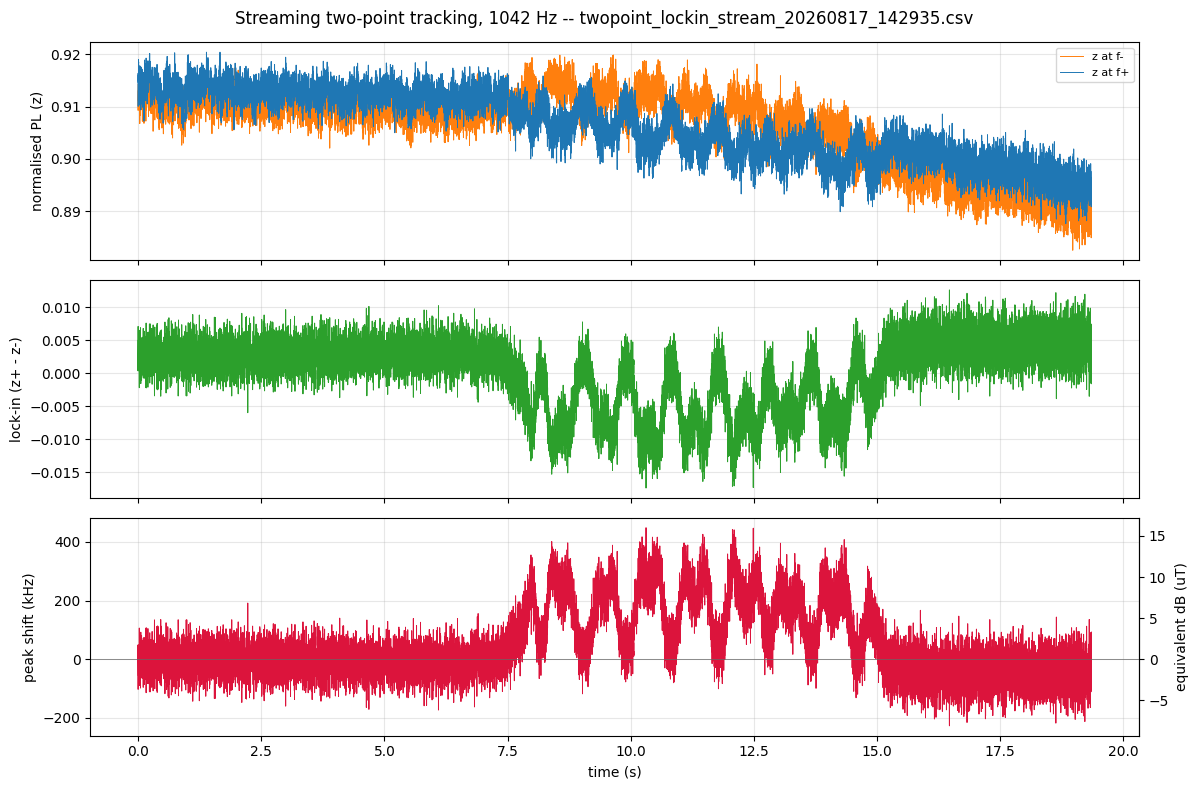

In [12]:
# Step 4b - Continuous streaming acquisition.
#
# Prefer this over Step 4's burst mode for anything above a few hundred Hz: one FPGA run,
# no per-batch reconfiguration, no duty-cycle hole, and no stale-buffer race by construction.
from copy import copy
from pathlib import Path
from time import perf_counter, time as _wallclock
from datetime import datetime
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

if "twopoint_delta_f_linear" not in globals():
    raise RuntimeError("Run Step 1b once before streaming -- it defines TWOPOINT_CALIB and "
                       "the conversion helpers.")

import importlib
import multipoint_lockin_program
multipoint_lockin_program = importlib.reload(multipoint_lockin_program)
from multipoint_lockin_program import MultipointLockinODMR

# --- Streaming parameters ---
STREAM_DURATION_SEC   = 30.0
STREAM_TARGET_HZ      = 1000.0   # None = keep every rep (full cadence, ~4.2 kHz at tau=120)
STREAM_PAIR_ORDER     = "forward"  # "abba" cancels linear common-mode drift; costs 2x per rep
STREAM_SKIP_REFERENCE = TWOPOINT_SKIP_REFERENCE if "TWOPOINT_SKIP_REFERENCE" in globals() else True
STREAM_RELAX_TREG     = 1000
STREAM_AUTOZERO_REPS  = 2000     # reps in the dedicated zero measurement before the run
STREAM_SHOW_PROGRESS  = False

_stamp = datetime.now().strftime("%Y%m%d_%H%M%S")
STREAM_CSV = TWOPOINT_DIR / f"twopoint_lockin_stream_{_stamp}.csv"
STREAM_CSV.parent.mkdir(parents=True, exist_ok=True)

# --- Build the streaming program. cfg.reps IS the run length: the tProc loops that many
# times and ends, so it has to be set before compilation and cannot change mid-run. ---
cfg_stream = copy(default_config)
cfg_stream.multipoint_freqs_mhz      = list(TWOPOINT_FREQS_MHZ)
cfg_stream.odmr_reference_offres_mhz = (TWOPOINT_OFF_RESONANCE_MHZ
                                        if "TWOPOINT_OFF_RESONANCE_MHZ" in globals() else 2700.0)
cfg_stream.multipoint_skip_reference = bool(STREAM_SKIP_REFERENCE)
cfg_stream.multipoint_pair_order     = str(STREAM_PAIR_ORDER)
cfg_stream.relax_delay_treg          = int(STREAM_RELAX_TREG)
cfg_stream.mw_start_fMHz             = float(TWOPOINT_FREQS_MHZ[0])
cfg_stream.mw_end_fMHz               = float(TWOPOINT_FREQS_MHZ[0])
cfg_stream.nsweep_points             = 1
cfg_stream.pre_init                  = False

_probe = MultipointLockinODMR(copy(cfg_stream))
_cadence = _probe.time_per_rep()
_total_reps = max(1, int(round(STREAM_DURATION_SEC / _cadence)))
cfg_stream.reps = _total_reps

prog_stream = MultipointLockinODMR(cfg_stream)

# Host-side averaging factor. Whole reps only, so the achieved rate is the cadence divided
# by an integer rather than exactly the target.
_bin = 1 if STREAM_TARGET_HZ is None else max(1, int(round(1.0 / (STREAM_TARGET_HZ * _cadence))))
_achieved_hz = 1.0 / (_bin * _cadence)

print(prog_stream.describe_timing())
print(f"Raw cadence      : {_cadence * 1e6:.1f} us/rep -> {1 / _cadence:.0f} Hz")
print(f"Host averaging   : {_bin} rep(s)/sample -> {_achieved_hz:.1f} Hz"
      + ("" if STREAM_TARGET_HZ is None else f" (target {STREAM_TARGET_HZ:.0f} Hz)"))
print(f"Run length       : {_total_reps} reps = {_total_reps * _cadence:.1f} s")
try:
    _head = prog_stream.stream_headroom()
    print(f"Buffer headroom  : {_head['shots_that_fit']} shots "
          f"({_head['seconds_that_fit']:.2f} s) fit in the {_head['avg_maxlen']}-entry buffer; "
          f"board transfers every ~{_head['worker_stride_shots']} shots")
except Exception as _e:
    print(f"Buffer headroom  : could not read avg_maxlen ({_e})")

# --- Priming acquire with pre_init=True, results discarded (same as Step 4) ---
cfg_prime = copy(cfg_stream)
cfg_prime.pre_init = True
cfg_prime.reps = 100
_prog_prime = MultipointLockinODMR(cfg_prime)
print("\nPriming spin polarization...")
_ = _prog_prime.acquire(progress=False)
del _prog_prime, cfg_prime
print("Priming done.")

# --- Auto-zero BEFORE the stream, not during it ---
# Without a per-shot reference the zero of (z+ - z-) no longer matches the ODMR sweep's, so
# it has to be measured on this run. Doing it inside the stream would convert the first
# samples against the calibration zero and the rest against the measured one, leaving a step
# in the middle of one file. A dedicated averaged acquire at pre_init=False costs one
# STREAM_AUTOZERO_REPS-long run and makes the whole stream self-consistent.
cfg_zero = copy(cfg_stream)
cfg_zero.reps = int(STREAM_AUTOZERO_REPS)
_prog_zero = MultipointLockinODMR(cfg_zero)
_d0 = _prog_zero.acquire(progress=False)
_r0 = _d0.reference if _d0.reference is not None else [None, None]
_zero_lockin = float(twopoint_z_from_counts(_d0.signal[1], _r0[1])
                     - twopoint_z_from_counts(_d0.signal[0], _r0[0]))
_calib_zero = float(TWOPOINT_CALIB["baseline_plus"]) - float(TWOPOINT_CALIB["baseline_minus"])
_denom = float(TWOPOINT_CALIB["slope_minus_per_mhz"]) - float(TWOPOINT_CALIB["slope_plus_per_mhz"])
print(f"Auto-zero over {STREAM_AUTOZERO_REPS} reps: (z+ - z-) zero = {_zero_lockin:+.6e} "
      f"(sweep said {_calib_zero:+.6e})")
print(f"  -> removes a constant {(_zero_lockin - _calib_zero) / _denom * 1e3:+.0f} kHz offset. "
      f"Shifts are measured from the start of this run, not from the ODMR sweep.")
del _prog_zero, cfg_zero, _d0, _r0
print("\nStreaming.\n")

# --- Stream, converting and writing incrementally ---
_gamma_nv = float(TWOPOINT_CALIB["gamma_nv_mhz_per_uT"])
_pending = []          # reps not yet forming a whole averaging bin
_rows = []
_csv_written = 0
_n_packets = 0
_t_wall_start = perf_counter()


def _flush_stream_csv():
    """Append rows recorded since the last flush; header written only once."""
    global _csv_written
    if len(_rows) == _csv_written:
        return
    pd.DataFrame(_rows[_csv_written:]).to_csv(
        STREAM_CSV, mode="w" if _csv_written == 0 else "a",
        header=(_csv_written == 0), index=False)
    _csv_written = len(_rows)


_last_save = perf_counter()
try:
    for _pkt in prog_stream.stream(total_reps=_total_reps, progress=STREAM_SHOW_PROGRESS):
        _n_packets += 1
        _sig = np.atleast_2d(np.asarray(_pkt.signal, dtype=float))
        _ref = (np.atleast_2d(np.asarray(_pkt.reference, dtype=float))
                if _pkt.reference is not None else None)

        # Bin whole reps. Leftovers carry into the next packet so no rep is dropped and
        # bins never straddle a gap -- there are no gaps in a stream.
        _start_rep = _pkt.first_rep
        if _pending:
            _sig = np.concatenate([_pending[0], _sig], axis=0)
            _ref = (np.concatenate([_pending[1], _ref], axis=0)
                    if _ref is not None and _pending[1] is not None else _ref)
            _start_rep -= _pending[0].shape[0]
            _pending = []

        _n_full = (_sig.shape[0] // _bin) * _bin
        if _n_full < _sig.shape[0]:
            _pending = [_sig[_n_full:], None if _ref is None else _ref[_n_full:]]
        if _n_full == 0:
            continue

        _sig_b = _sig[:_n_full].reshape(-1, _bin, _sig.shape[1]).mean(axis=1)
        _ref_b = (None if _ref is None
                  else _ref[:_n_full].reshape(-1, _bin, _ref.shape[1]).mean(axis=1))

        _zm = np.asarray(twopoint_z_from_counts(
            _sig_b[:, 0], None if _ref_b is None else _ref_b[:, 0]), dtype=float)
        _zp = np.asarray(twopoint_z_from_counts(
            _sig_b[:, 1], None if _ref_b is None else _ref_b[:, 1]), dtype=float)

        _df = np.asarray(twopoint_delta_f_linear(_zm, _zp, zero_lockin=_zero_lockin),
                         dtype=float)
        # Timestamps from the FPGA cadence, never from arrival time.
        _t = (_start_rep + (np.arange(_sig_b.shape[0]) + 0.5) * _bin) * _cadence
        _now = _wallclock()

        for _k in range(_sig_b.shape[0]):
            _rows.append({
                "packet": _n_packets,
                "rep_index": int(_start_rep + _k * _bin),
                "reps_averaged": _bin,
                "time_s": float(_t[_k]),
                "timestamp_epoch_s": _now,
                "peak_01": float(_sig_b[_k, 0]),
                "peak_01_freq_mhz": float(_pkt.frequencies_mhz[0]),
                "peak_02": float(_sig_b[_k, 1]),
                "peak_02_freq_mhz": float(_pkt.frequencies_mhz[1]),
                "z_minus": float(_zm[_k]),
                "z_plus": float(_zp[_k]),
                "lockin_signal": float(_zp[_k] - _zm[_k]),
                "delta_f_mhz": float(_df[_k]),
                "peak_shift_kHz": float(_df[_k]) * 1e3,
                "f_new_mhz": float(TWOPOINT_CALIB["f0_mhz"]) + float(_df[_k]),
                "B_shift_uT": float(_df[_k]) / _gamma_nv,
            })

        if perf_counter() - _last_save > 5.0:
            _flush_stream_csv()
            _last_save = perf_counter()
except KeyboardInterrupt:
    print(f"Stream stopped by user after {len(_rows)} samples.")
finally:
    _flush_stream_csv()

_wall = perf_counter() - _t_wall_start
df_stream = pd.DataFrame(_rows)

# --- Summary ---
print(f"\nStream finished: {len(df_stream)} samples from {_n_packets} packets "
      f"in {_wall:.1f} s wall clock")
if len(df_stream):
    _span = float(df_stream["time_s"].iloc[-1] - df_stream["time_s"].iloc[0])
    _reps_seen = int(df_stream["rep_index"].iloc[-1] + _bin)
    print(f"  FPGA time covered   : {_reps_seen * _cadence:.2f} s over {_reps_seen} reps")
    print(f"  duty cycle          : {100 * _reps_seen * _cadence / _wall:.1f}% "
          f"(streaming has no inter-burst gap; the remainder is setup)")
    print(f"  sample rate         : {len(df_stream) / _span:.1f} Hz "
          f"(target {STREAM_TARGET_HZ})")
    _dt = np.diff(df_stream["time_s"].to_numpy())
    print(f"  timestamp spacing   : {_dt.min() * 1e6:.1f} - {_dt.max() * 1e6:.1f} us "
          f"(uniform by construction; jitter here means dropped reps)")
    _sh = df_stream["peak_shift_kHz"].to_numpy(float)
    _sh = _sh[np.isfinite(_sh)]
    if _sh.size:
        print(f"  peak shift          : mean {_sh.mean():+.1f} kHz, std {_sh.std():.1f} kHz")
        print(f"  equivalent field    : std {_sh.std() * 1e-3 / _gamma_nv:.3f} uT, "
              f"eta ~ {_sh.std() / _gamma_nv * np.sqrt(_bin * _cadence):.0f} nT/rtHz")
print(f"Saved to: {STREAM_CSV}")
display(FileLink(str(STREAM_CSV)))

if len(df_stream):
    fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)
    axes[0].plot(df_stream["time_s"], df_stream["z_minus"], lw=0.7,
                 color="tab:orange", label="z at f-")
    axes[0].plot(df_stream["time_s"], df_stream["z_plus"], lw=0.7,
                 color="tab:blue", label="z at f+")
    axes[0].set_ylabel("normalised PL (z)"); axes[0].legend(fontsize=8)
    axes[1].plot(df_stream["time_s"], df_stream["lockin_signal"], lw=0.7, color="tab:green")
    axes[1].set_ylabel("lock-in (z+ - z-)")
    axes[2].plot(df_stream["time_s"], df_stream["peak_shift_kHz"], lw=0.7, color="crimson")
    axes[2].axhline(0, color="0.4", lw=0.5)
    axes[2].set_ylabel("peak shift (kHz)"); axes[2].set_xlabel("time (s)")
    _ax_b = axes[2].secondary_yaxis(
        "right", functions=(lambda k: k * 1e-3 / _gamma_nv, lambda u: u * _gamma_nv * 1e3))
    _ax_b.set_ylabel("equivalent dB (uT)")
    for _a in axes:
        _a.grid(True, alpha=0.3)
    fig.suptitle(f"Streaming two-point tracking, {_achieved_hz:.0f} Hz -- {STREAM_CSV.name}")
    plt.tight_layout()
    plt.show()


## Step 5 - Post-processing the live run

Reads the CSV written by Step 4 (or any earlier one via `LIVE_CSV_OVERRIDE`) and produces
the four-panel summary, the equivalent of the QDM-heart peak-shift figure plus a noise
spectrum:

1. normalised PL at both parked frequencies, against the calibration baselines
2. lock-in signal `z+ - z-`
3. peak shift in kHz, with the equivalent NV-axis field on the right axis
4. amplitude spectral density of the shift, in nT/sqrt(Hz)

`SHIFT_REFERENCE` re-zeroes the trace: `"calibration"` keeps the absolute shift against the
Step 1 ODMR fit, `"first"` and `"mean"` remove the constant offset so only the time
structure remains. The offset between `"calibration"` and `"mean"` is a real number worth
reading - it is the drift between the ODMR sweep and the run.

Processing: twopoint_lockin_live_20260817_120659.csv
  188000 samples over 30.0 s (6257.6 Hz)
  BURST run: 376 acquires x ~500 samples, 25 us apart inside a burst (39264 Hz within-burst rate)
  duty cycle 16% (rest is the ~67 ms host overhead between bursts)

Reference: calibration
Peak shift: mean +56.78 kHz, std 149.83 kHz, pk-pk 1067.20 kHz
Equivalent field along this NV axis: std 5.347 uT, pk-pk 38.082 uT
Sample rate 4281.1 Hz -> white-noise floor ~116 nT/sqrt(Hz) (valid only if the trace is white; read panel 4)
Shift range is 14.2% of the 7514 kHz linewidth (well inside the linear range)

ASD note: burst data is not uniformly sampled -- samples are dense inside a burst
and absent in the ~10 ms gap between bursts. The FFT below treats them as uniform, so
it is trustworthy well below 1/(burst period) and develops comb artefacts near the
within-burst Nyquist. For a clean spectrum, analyse one burst at a time.


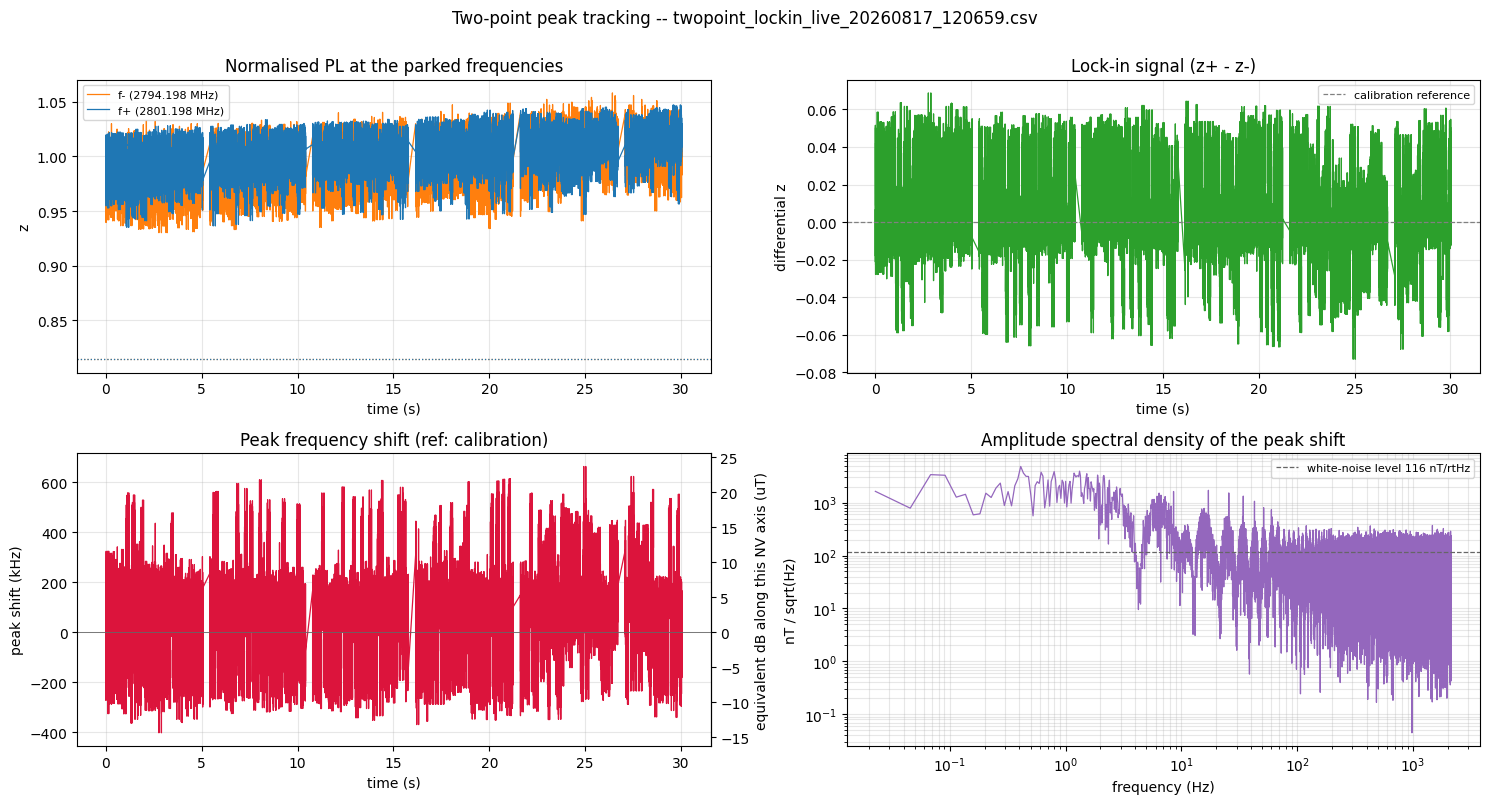


Saved C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_live_20260817_120659_peakshift_calibration.csv
Saved C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_live_20260817_120659_summary.csv


C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_live_20260817_120659_peakshift_calibration.csv

C:\Users\Thoma\Downloads\nv-compact-magnetometer\data\twopoint_lockin\twopoint_lockin_live_20260817_120659_summary.csv

In [13]:
# Step 5 - Post-processing: peak-shift time series, statistics and noise spectrum.
# Works standalone on any CSV written by Step 4 (all derived columns are already in it).
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import FileLink, display

LIVE_CSV_OVERRIDE = None      # Path("...twopoint_lockin_live_....csv") to process an older run
SHIFT_REFERENCE = "calibration"   # "calibration" | "first" | "mean"
ASD_DETREND = True                # remove a linear drift before the spectrum

# --- Resolve which CSV to process ---
if LIVE_CSV_OVERRIDE is not None:
    _csv_to_load = Path(LIVE_CSV_OVERRIDE)
elif "LIVE_CSV" in globals() and Path(LIVE_CSV).exists():
    _csv_to_load = Path(LIVE_CSV)
else:
    _dir = PROJECT_ROOT / "data" / "twopoint_lockin"
    _candidates = sorted(_dir.glob("twopoint_lockin_live_*.csv"))
    if not _candidates:
        raise FileNotFoundError(f"No twopoint_lockin_live_*.csv found in {_dir}")
    _csv_to_load = _candidates[-1]
print(f"Processing: {_csv_to_load.name}")

dfl = pd.read_csv(_csv_to_load)
if "peak_shift_kHz" not in dfl.columns:
    raise RuntimeError("No peak_shift_kHz column -- was this CSV produced by Step 4?")

t = dfl["time_s"].to_numpy(float)
print(f"  {len(dfl)} samples over {t[-1]:.1f} s ({len(dfl)/t[-1]:.1f} Hz)")
# Burst runs carry several samples per acquire, so the sample spacing inside a burst is
# not the acquire period. Detect it from the batch column and treat the two cases apart.
_BURST = "batch" in dfl.columns and dfl["batch"].nunique() < len(dfl)
_per_burst = len(dfl) / dfl["batch"].nunique() if _BURST else 1
if _BURST:
    _dt_in = float(np.median(np.diff(t[dfl["batch"] == dfl["batch"].iloc[0]])))
    print(f"  BURST run: {dfl['batch'].nunique()} acquires x ~{_per_burst:.0f} samples, "
          f"{_dt_in*1e6:.0f} us apart inside a burst ({1/_dt_in:.0f} Hz within-burst rate)")
if "acq_seconds" in dfl.columns and len(dfl) > 1:
    _pulse_time = len(dfl) * (_dt_in if _BURST else float(np.median(np.diff(t))))
    _duty = _pulse_time / float(t[-1]) if t[-1] > 0 else float("nan")
    if _BURST:
        _duty = len(dfl) * _dt_in / float(t[-1])
        print(f"  duty cycle {100*_duty:.0f}% (rest is the ~{dfl['acq_seconds'].median()*1e3:.0f} ms "
              f"host overhead between bursts)")
    else:
        _duty = dfl["acq_seconds"].median() / float(np.median(np.diff(t)))
        print(f"  duty cycle {100*_duty:.0f}% (fraction of wall time actually integrating signal)")
        if _duty < 0.5:
            print("  -> Over half the run is overhead. Raise LIVE_PLOT_REFRESH_EVERY or set "
                  "LIVE_SHOW_PLOT = False; the live redraw is usually the culprit.")

# --- Re-reference the shift ---
# NaN-safe: CSVs written before the exact Lorentzian inversion was removed can contain
# NaN peak_shift_kHz wherever that estimator had no physical root. The current Step 4
# cannot produce one, so a non-empty count here means an older file.
_shift = dfl["peak_shift_kHz"].to_numpy(float)
ok = np.isfinite(_shift)
n_bad = int((~ok).sum())
if n_bad:
    print(f"  {n_bad}/{len(dfl)} samples are NaN -- this CSV predates the removal of the exact "
          f"depth-ratio inversion. They are excluded below; re-acquire for a clean run.")
if not ok.any():
    raise RuntimeError("Every peak_shift_kHz sample is NaN -- nothing to process.")
if SHIFT_REFERENCE == "calibration":
    _zero = 0.0
elif SHIFT_REFERENCE == "first":
    _zero = float(_shift[ok][0])
elif SHIFT_REFERENCE == "mean":
    _zero = float(np.mean(_shift[ok]))
else:
    raise ValueError(f"Unknown SHIFT_REFERENCE: {SHIFT_REFERENCE!r}")
shift = _shift - _zero

# gamma_NV in MHz per microtesla: prefer the run's own calibration, else the default.
_gamma_nv = float(TWOPOINT_CALIB["gamma_nv_mhz_per_uT"]) if "TWOPOINT_CALIB" in globals() else 28.024e-3
B_uT = shift * 1e-3 / _gamma_nv

# --- Statistics ---
_dt = float(np.median(np.diff(t))) if len(t) > 1 else float("nan")
_rate = 1.0 / _dt if _dt > 0 else float("nan")
_sigma_khz = float(shift[ok].std())
_sigma_uT = _sigma_khz * 1e-3 / _gamma_nv
# White-noise sensitivity: sigma over one sample of duration dt corresponds to
# sigma * sqrt(2 * dt) (single-sided, sqrt(2 dt) = 1/sqrt(bandwidth)).
_sens_uT_rtHz = _sigma_uT * np.sqrt(2.0 * _dt) if np.isfinite(_dt) else float("nan")

print(f"\nReference: {SHIFT_REFERENCE}" + ("" if SHIFT_REFERENCE == "calibration" else
      f" (removed a constant {_zero:+.1f} kHz vs the Step 1b calibration zero)"))
print(f"Peak shift: mean {shift[ok].mean():+.2f} kHz, std {_sigma_khz:.2f} kHz, "
      f"pk-pk {np.ptp(shift[ok]):.2f} kHz")
print(f"Equivalent field along this NV axis: std {_sigma_uT:.3f} uT, pk-pk {np.ptp(B_uT[ok]):.3f} uT")
print(f"Sample rate {_rate:.1f} Hz -> white-noise floor ~{_sens_uT_rtHz*1e3:.0f} nT/sqrt(Hz) "
      f"(valid only if the trace is white; read panel 4)")
if "TWOPOINT_CALIB" in globals():
    _fwhm_khz = TWOPOINT_CALIB["fwhm_mhz"] * 1e3
    _ptp = np.ptp(shift[ok])
    print(f"Shift range is {100*_ptp/_fwhm_khz:.1f}% of the {_fwhm_khz:.0f} kHz linewidth "
          f"({'well inside the linear range' if _ptp < 0.2*_fwhm_khz else 'beyond the linear range -- re-run Steps 1a/1b'})")

# --- Amplitude spectral density of the shift ---
_asd_f = _asd = None
if _BURST:
    print("\nASD note: burst data is not uniformly sampled -- samples are dense inside a burst\n"
          "and absent in the ~10 ms gap between bursts. The FFT below treats them as uniform, so\n"
          "it is trustworthy well below 1/(burst period) and develops comb artefacts near the\n"
          "within-burst Nyquist. For a clean spectrum, analyse one burst at a time.")
if ok.sum() >= 16 and np.isfinite(_dt) and _dt > 0:
    _t_ok = t[ok]
    x = B_uT[ok].astype(float)
    if ASD_DETREND:
        x = x - np.polyval(np.polyfit(_t_ok, x, 1), _t_ok)
    n = x.size
    w = np.hanning(n)
    X = np.fft.rfft(x * w)
    _asd_f = np.fft.rfftfreq(n, _dt)
    psd = 2.0 * np.abs(X) ** 2 * _dt / (n * np.mean(w ** 2))   # one-sided, uT^2/Hz
    _asd = np.sqrt(psd) * 1e3                                   # -> nT/sqrt(Hz)
    _asd_f, _asd = _asd_f[1:], _asd[1:]                         # drop DC

# --- Four-panel figure ---
fig, axes = plt.subplots(2, 2, figsize=(15, 8))
ax0, ax1, ax2, ax3 = axes[0, 0], axes[0, 1], axes[1, 0], axes[1, 1]

_f_minus = float(dfl["peak_01_freq_mhz"].iloc[0]) if "peak_01_freq_mhz" in dfl else float("nan")
_f_plus = float(dfl["peak_02_freq_mhz"].iloc[0]) if "peak_02_freq_mhz" in dfl else float("nan")
ax0.plot(t, dfl["z_minus"], lw=0.9, color="tab:orange", label=f"f- ({_f_minus:.3f} MHz)")
ax0.plot(t, dfl["z_plus"],  lw=0.9, color="tab:blue",   label=f"f+ ({_f_plus:.3f} MHz)")
if "TWOPOINT_CALIB" in globals():
    ax0.axhline(TWOPOINT_CALIB["baseline_minus"], color="tab:orange", ls=":", lw=0.9)
    ax0.axhline(TWOPOINT_CALIB["baseline_plus"],  color="tab:blue",   ls=":", lw=0.9)
ax0.set(title="Normalised PL at the parked frequencies", xlabel="time (s)", ylabel="z")
ax0.legend(fontsize=8)

ax1.plot(t, dfl["lockin_signal"], lw=0.9, color="tab:green")
if "TWOPOINT_CALIB" in globals():
    ax1.axhline(TWOPOINT_CALIB["baseline_plus"] - TWOPOINT_CALIB["baseline_minus"],
                color="0.5", ls="--", lw=0.9, label="calibration reference")
    ax1.legend(fontsize=8)
ax1.set(title="Lock-in signal (z+ - z-)", xlabel="time (s)", ylabel="differential z")

ax2.plot(t, shift, lw=0.9, color="crimson")
ax2.axhline(0, color="0.4", lw=0.6)
ax2.set(title=f"Peak frequency shift (ref: {SHIFT_REFERENCE})", xlabel="time (s)",
        ylabel="peak shift (kHz)")
_axb = ax2.secondary_yaxis("right",
                           functions=(lambda k: k * 1e-3 / _gamma_nv,
                                      lambda u: u * _gamma_nv * 1e3))
_axb.set_ylabel("equivalent dB along this NV axis (uT)")

if _asd is not None:
    ax3.loglog(_asd_f, _asd, lw=0.9, color="tab:purple")
    ax3.axhline(_sens_uT_rtHz * 1e3, color="0.4", ls="--", lw=0.9,
                label=f"white-noise level {_sens_uT_rtHz*1e3:.0f} nT/rtHz")
    ax3.set(title="Amplitude spectral density of the peak shift",
            xlabel="frequency (Hz)", ylabel="nT / sqrt(Hz)")
    ax3.legend(fontsize=8)
else:
    ax3.text(0.5, 0.5, "not enough samples for an ASD", ha="center", va="center",
             transform=ax3.transAxes)
    ax3.set_axis_off()

for _a_ in (ax0, ax1, ax2, ax3):
    _a_.grid(True, alpha=0.3, which="both")
fig.suptitle(f"Two-point peak tracking -- {_csv_to_load.name}", y=1.00)
plt.tight_layout()
plt.show()

# --- Save the processed table + a one-row summary ---
out = pd.DataFrame({
    "time_s": t,
    "z_minus": dfl["z_minus"],
    "z_plus": dfl["z_plus"],
    "lockin_signal": dfl["lockin_signal"],
    "peak_shift_kHz": shift,
    "B_shift_uT": B_uT,
})
PROCESSED_CSV = _csv_to_load.with_name(_csv_to_load.stem + f"_peakshift_{SHIFT_REFERENCE}.csv")
out.to_csv(PROCESSED_CSV, index=False)

SUMMARY_CSV = _csv_to_load.with_name(_csv_to_load.stem + "_summary.csv")
pd.DataFrame([{
    "csv": _csv_to_load.name,
    "n_batches": len(dfl),
    "duration_s": float(t[-1]),
    "rate_Hz": _rate,
    "shift_reference": SHIFT_REFERENCE,
    "n_nan": n_bad,
    "shift_mean_kHz": float(shift[ok].mean()),
    "shift_std_kHz": _sigma_khz,
    "shift_ptp_kHz": float(np.ptp(shift[ok])),
    "B_std_uT": _sigma_uT,
    "sensitivity_uT_per_rtHz": _sens_uT_rtHz,
    "f0_calibration_mhz": float(TWOPOINT_CALIB["f0_mhz"]) if "TWOPOINT_CALIB" in globals() else np.nan,
    "fwhm_calibration_mhz": float(TWOPOINT_CALIB["fwhm_mhz"]) if "TWOPOINT_CALIB" in globals() else np.nan,
}]).to_csv(SUMMARY_CSV, index=False)

print(f"\nSaved {PROCESSED_CSV}")
print(f"Saved {SUMMARY_CSV}")
display(FileLink(str(PROCESSED_CSV)))
display(FileLink(str(SUMMARY_CSV)))

## Caveats

- **No vector field.** Two parked points constrain one resonance frequency. The `B_shift_nT`
  column is `df / gamma_NV` - the field change projected on the tracked NV axis, and only
  under the assumption that the shift is Zeeman in origin. Temperature drift moves `D` and
  therefore moves every resonance too, and a single peak cannot tell the two apart. Use
  `Lockin_module.ipynb` when you need `dBx, dBy, dBz`.
- **The calibration is the ODMR sweep.** FWHM, baseline and flank slopes all come from one
  spectrum. Retake it whenever the bias field, MW power or laser power changes. The Step 2
  overlay is the check: a large common offset between the parked z values and the
  calibration baselines means the reference has gone stale.
- **Method A cancels contrast, not linewidth.** Common-mode laser-power drift drops out of
  the depth ratio, but a wrong FWHM rescales every shift by a constant factor. The shape of
  the trace is trustworthy before the kHz axis is.
- **Single-Lorentzian model.** Unresolved 14N hyperfine (three lines, 2.16 MHz apart) makes a
  narrow peak non-Lorentzian in detail, which biases the absolute `f0` more than the relative
  shift. If the sweep resolves the structure, narrow `FIT_WINDOW_MHZ` onto one component and
  park inside it - the symmetry score in Step 1 is there to steer you toward peaks where
  this is least bad.
- **Linear range.** Method B is only valid while the shift is a small fraction of the
  linewidth. Step 5 prints the shift range as a percentage of the FWHM; past ~20% believe
  method A and treat B as a diagnostic.
- **Out-of-range shifts give NaN.** If the peak moves far enough that a parked point rises
  above the fitted baseline, the depth ratio has no physical root and `f0` is NaN. Widen the
  parked spacing (`PLACEMENT_MODE = "symmetric_half_max"` parks further out) or re-run
  Step 1 at the new field.